# Entrega 1 sprint
Llegamos al final del primer sprint y estamos en condiciones de analizar un dataset, entrenar un primer modelo (de regresión o clasificación) y evaluar resultados.

En este proyecto, trabajaremos con un dataset que contiene información sobre personas. La idea es predecir si la persona tiene un salario anual mayor a 50K dólares.

### Consignas:

A diferencia de los trabajos que venimos haciendo en clases, en los cuáles nos íbamos guiando por consignas o tips en un notebook, en este caso les toca a ustedes definir qué análisis les parece necesario hacer, qué algoritmo utilizar y qué métrica medir (justificando por qué).

La idea es que el notebook sea una especie de "informe" en el que ustedes puedan explicar de forma simple a una persona cualquiera lo que hicieron. Aprovechen las celdas de texto y agreguen los gráficos que les parezca necesarios. Como primer paso, deben identificar si se trata de un problema de regresión o clasificación, hacer un análisis exploratorio de los datos (presentando conclusiones siempre) y finalmente entrenar un modelo para generar sus predicciones.

Si les es útil, pueden agregar datos de otras fuentes (por ejemplo datasets públicos del país, o lo que sea) siempre justificando sus decisiones.

Son libres de probar cualquiera de los modelos que vimos, pueden dejar los resultados de todo lo que prueben con sus correspondientes conclusiones para mostrar cómo llegan al resultado final.

Se les entrega 3 archivos:
- train.csv: Es el dataset que utilizarán para entrenar su modelo. Contiene features y el target
- test.csv: Este archivo, contiene únicamente features (incluyendo el ID de la persona). Ustedes deben predecir el target para todas estas personas y armar un archivo que contenga las columnas ID, PRED
- submit_example.csv: El archivo que entreguen tiene que tener exactamente este formato, pero con sus predicciones. Es decir, tiene que contener las columnas ID (que se corresponde al ID de la persona en el set test.csv) y PRED (que toma los valores 1 y 0. 1 significa que la persona gana más de 50K y 0 significa que no).

Deben entregar:
- Notebook con análisis e implementación del modelo predictivo
- Archivo en formato csv con las predicciones para el set de test.

## A tener en cuenta

- En la columna workclass van a ver los valores: 'Self-emp-not-inc' y 'Self-emp-inc' [acá](https://smallbiztrends.com/2013/11/incorporated-versus-unincorporated-self-employment.html) pueden encontrar info sobre su significado.
- Con pandas tienen la función to_csv que les permite exportar un dataframe a csv. Recuerden que tienen que especificar en el parámetro index, que no quieren que el index quede en el archivo csv.

## Archivos

Los archivos necesarios pueden descargarlos de los siguientes links:

- [train.csv](https://drive.google.com/file/d/1BrkSis0Wen2csQndEr2BIxEwneRgq4e8/view?usp=drive_link)
- [test.csv](https://drive.google.com/file/d/1sM-rZHlfjLFvhe7313lVEUHPe5YpxnaI/view?usp=sharing)
- [submit_example.csv](https://drive.google.com/file/d/1AAgSFR8HWaKKefhbrbSrMBSrRZHDA7nV/view?usp=sharing)

## Fecha de entrega

La entrega se tiene que enviar por mail (puede ser un link a google drive) a iandatascientistia@gmail.com

1 entrega por grupo / persona individual (En caso de que sea entrega grupal, indicar el nombre de todos los integrantes en el mail o al comienzo del notebook).

Fecha limite de entrega: Clase 27 (lunes 21/04/2025).

In [ ]:
# <-- Librerias y modulos para analisis y manipulación de datos -->
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# <-- sklearn: Modulos para procesamiento de datos -->
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder

# <-- sklearn: Modulos para machine learning -->
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# <-- Librerias adicionales -->
import joblib

Funciones personalizadas

In [ ]:
def bins_calculator_fd(df:pd.DataFrame, column:str) -> int:
    '''
    args:
    - df (pandas.DataFrame): DataFrame sobre el que se calculara la cantidad de bins en una columna especifica.
    - column (str): Columna del DataFrame sobre la que se calculara la cantidad de bins.
    returns:
    - n_bins (int): Cantidad de bins para la columna, utilizando la formula de Freedman-Diaconis.
    '''

    # cálculo de IQR
    q1 = np.quantile(df[column], 0.25)
    q3 = np.quantile(df[column], 0.75)
    iqr = q3 - q1

    # cálculo de ancho de bins
    h_bins = (2 * iqr) / (df[column].shape[0] ** (1/3))

    # cálculo de n_bins
    n_bins = (max(df[column]) - min(df[column])) / h_bins

    return int(n_bins)

In [ ]:
def limite_outliers(df: pd.DataFrame, column: str):
    '''
    Esta función recibe un dataframe junto con una columna, de la cual extraera el limite superior e inferior que separara los valores atípicos.

    args:
    - df (pandas.DataFrame): DataFrame de Pandas.
    - column (string): Nombre de la columna.

    returns:
    - (dict): Diccionario con limite inferior y superior
    '''

    if pd.api.types.is_numeric_dtype(df[column]):
        # definiendo los quartiles y el IQR según la formula de Tukey
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        # definiendo el limite inferior y superior para detectar los outliers

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        return dict([('limite_inferior' ,limite_inferior), ('limite_superior', limite_superior)])

Seteo de parámetros por defecto

In [ ]:
# uso por defecto de tema de 'tableau'
plt.style.use('tableau-colorblind10')

# Parámetros base personalizados
matplotlib_base_params = {
    'figure.figsize': (10, 10),  # Tamaño de la figura
    'axes.labelsize': 12,        # Tamaño de la fuente de las etiquetas de los ejes
    'axes.titlesize': 14,        # Tamaño de la fuente del título de los ejes
    'xtick.labelsize': 10,       # Tamaño de la fuente de las marcas del eje X
    'ytick.labelsize': 10      # Tamaño de la fuente de las marcas del eje Y
    #'font.sans-serif': 'Verdana' # Fuente sans-serif
}


plt.rcParams.update(matplotlib_base_params)

# diccionario para definir la paleta de colores para la columna target
colores_income_annual = {
    '<=50K': '#FF9999',   # Rojo suave
    '>50K': '#66B3FF',  # Azul pastel
}

In [ ]:
# parámetros por defecto para pandas
pandas_options_dict = {
    'display.max_rows': 100,
    'display.max_columns': 100,
    'display.max_colwidth': None,
    'display.float_format': '{:.2f}'.format,
    'display.width': 120,
    'mode.use_inf_as_na': True,
}

for option, valor in pandas_options_dict.items():
  pd.set_option(option, valor)

np.random.seed(42)

<ipython-input-5-83eed8628b5a>:12: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option(option, valor)


Lectura del dataset

In [ ]:
# dataset de train
train_id = '1BrkSis0Wen2csQndEr2BIxEwneRgq4e8'
url = f'https://drive.google.com/uc?id={train_id}'
df_train = pd.read_csv(url)

In [ ]:
df_train.sample(n=3)

,index,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,ID
11333,22561,35,Private,Assoc-acdm,12,Married-civ-spouse,Other-service,Wife,White,Female,0,0,35,United-States,>50K,22552
23361,22639,57,Private,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K,22630
25207,13624,26,Private,HS-grad,9,Never-married,Tech-support,Other-relative,Black,Male,0,0,40,?,<=50K,13621


In [ ]:
# dataset de test
test_id = '1sM-rZHlfjLFvhe7313lVEUHPe5YpxnaI'
url = f'https://drive.google.com/uc?id={test_id}'
df_test = pd.read_csv(url)

In [ ]:
df_test.sample(3)

,index,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,ID
3484,31779,27,Private,HS-grad,9,Never-married,Farming-fishing,Other-relative,White,Male,0,0,40,Mexico,31757
289,19953,40,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,19946
94,26542,40,Federal-gov,Some-college,10,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,26527


## EDA

### Contexto y objetivo de la exploración

#### Información sobre el conjunto de datos

Este dataset contiene información personal sobre personas y el salario de cada uno en formato bianrio respecto a si gana mas o menos de 50K dólares anuales.

Las columnas features de este conjunto de datos son:
- ID -> ID de la persona dentro del registro
- age	-> Edad de la persona
- workclass	-> Sector donde trabaja (privado, estatal, etc.)
- education	-> Ultimo nivel educativo alcanzado
- education.num	-> Ańos de estudios
- marital.status -> Estado civil
- occupation	-> Ocupación profesional
- relationship	-> Esta en una relación de pareja?
- race	-> Raza
- sex	-> Sexo de la persona
- capital.gain	-> Capital ganado
- capital.loss	-> Capital perdido
- hours.per.week	-> Horas trabajadas por semana
- native.country	-> Pais natal

Las columna target de este conjunto de datos es:
- income	-> La persona gana mas de 50k us al ańo?


#### Objetivo del analisis

Se buscara información particular sobre cada una de las columnas con el objetivo de identificar preprocesamientos adecuados para cada una en cuanto a outliers, valores nulos, codificación y escalamiento; en segundo lugar tambien se identificara relaciónes entre caracateristics de las diferentes personas respecto a la columna target 'income' con el objetivo de en la etapa de ML entrenar los modelos que mejor se ajusten a las caracteristicas del conjunto de datos.

# EDA y tratamiento de datos

---

## Exploración inicial del conjunto de datos

### Dimensionalidad

In [ ]:
# Dimensionalidad del dataframe
df_train.shape

(27656, 16)

In [ ]:
df_train.sample(n=3, random_state=42)

,index,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,ID
11333,22561,35,Private,Assoc-acdm,12,Married-civ-spouse,Other-service,Wife,White,Female,0,0,35,United-States,>50K,22552
23361,22639,57,Private,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K,22630
25207,13624,26,Private,HS-grad,9,Never-married,Tech-support,Other-relative,Black,Male,0,0,40,?,<=50K,13621


In [ ]:
# Dimensionalidad del dataframe
df_test.shape

(4881, 15)

In [ ]:
df_test.sample(n=3, random_state=42)

,index,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,ID
2694,26279,43,Private,HS-grad,9,Separated,Other-service,Not-in-family,Black,Female,0,0,40,United-States,26264
724,17368,38,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,17362
297,11491,27,Private,HS-grad,9,Divorced,Adm-clerical,Unmarried,White,Female,0,0,45,United-States,11489


### Nombre de columnas

In [ ]:
# set de la columna 'ID' como indice en dataframe de entrenameinto
df_train.set_index('ID', inplace=True)

# set de la columna 'ID' como indice en dataframe de testeo
df_test.set_index('ID', inplace=True)

In [ ]:
cols_nuevos_nombres = {
    'age': 'age',
    'workclass': 'work_sector',
    'education': 'highest_education_level',
    'marital.status': 'marital_status',
    'occupation': 'current_occupation',
    'relationship': 'marital_relationship',
    'race': 'race',
    'education.num': 'years_of_education',
    'sex': 'binary_gender',
    'capital.gain': 'annual_capital_gain',
    'capital.loss': 'annual_capital_loss',
    'hours.per.week': 'weekly_work_hours',
    'native.country': 'native_country',
    'income': 'annual_income'
}

# Rnombramiento de columnas del dataframe de entrenamiento a un nombre mas descriptivo
df_train.rename(columns=cols_nuevos_nombres, inplace=True)

# Rnombramiento de columnas del dataframe de testeo a un nombre mas descriptivo
df_test.rename(columns=cols_nuevos_nombres, inplace=True)

In [ ]:
# copiando el dataframe original de entrenamiento en variable donde se le aplicara limpieza
df_limpio = df_train.copy()

In [ ]:
# Eliminación de columnas inecesarias
df_limpio.drop(columns=['index', 'marital_relationship'], inplace=True)
# en test
df_test.drop(columns=['index', 'marital_relationship'], inplace=True)

In [ ]:
# creación de columnas derivadas
df_limpio['annual_net_capital'] = df_limpio['annual_capital_gain'] - df_limpio['annual_capital_loss']
df_test['annual_net_capital'] = df_test['annual_capital_gain'] - df_test['annual_capital_loss']

### Tipo de dato de cada columna

In [ ]:
# Tipos de datos
df_limpio.dtypes

,0
age,int64
work_sector,object
highest_education_level,object
years_of_education,int64
marital_status,object
current_occupation,object
race,object
binary_gender,object
annual_capital_gain,int64
annual_capital_loss,int64


### Valores nulos

In [ ]:
df_limpio.isnull().sum()

,0
age,0
work_sector,0
highest_education_level,0
years_of_education,0
marital_status,0
current_occupation,0
race,0
binary_gender,0
annual_capital_gain,0
annual_capital_loss,0


#### Nulos implicitos

In [ ]:
valores_unicos_columnas = pd.Series([])

for col in df_limpio.columns:
  valores_unicos_columnas[col] = df_limpio[col].unique()
valores_unicos_columnas.name = 'Valores unicos'

valores_unicos_columnas

,Valores unicos
age,"[30, 37, 41, 45, 28, 32, 31, 59, 57, 42, 54, 26, 49, 66, 44, 39, 20, 24, 62, 29, 64, 58, 47, 23, 22, 51, 55, 40, 61, 69, 60, 33, 36, 56, 72, 21, 74, 67, 48, 68, 63, 25, 18, 19, 52, 34, 50, 35, 17, 82, 43, 27, 38, 84, 46, 90, 53, 71, 70, 76, 65, 73, 80, 75, 77, 79, 78, 81, 85, 88, 83, 87, 86]"
work_sector,"[Local-gov, Private, Federal-gov, Self-emp-not-inc, ?, State-gov, Self-emp-inc, Without-pay, Never-worked]"
highest_education_level,"[HS-grad, Bachelors, Some-college, 7th-8th, Assoc-voc, Masters, Assoc-acdm, 1st-4th, 5th-6th, Prof-school, 9th, 10th, 11th, 12th, Doctorate, Preschool]"
years_of_education,"[9, 13, 10, 4, 11, 14, 12, 2, 3, 15, 5, 6, 7, 8, 16, 1]"
marital_status,"[Divorced, Married-civ-spouse, Never-married, Widowed, Separated, Married-spouse-absent, Married-AF-spouse]"
current_occupation,"[Protective-serv, Exec-managerial, Craft-repair, Prof-specialty, Tech-support, Other-service, Transport-moving, Adm-clerical, Farming-fishing, Handlers-cleaners, ?, Sales, Machine-op-inspct, Priv-house-serv, Armed-Forces]"
race,"[White, Black, Asian-Pac-Islander, Amer-Indian-Eskimo, Other]"
binary_gender,"[Female, Male]"
annual_capital_gain,"[0, 7688, 7298, 3781, 1424, 20051, 2202, 4865, 4386, 14084, 15024, 99999, 3103, 1506, 2174, 3325, 4787, 13550, 2050, 6514, 3674, 8614, 14344, 991, 3411, 2176, 3137, 5455, 25124, 4934, 2829, 1086, 2597, 4508, 10520, 3908, 1151, 2354, 5013, 3942, 4650, 25236, 9386, 3471, 5178, 1409, 1055, 4416, 3418, 1797, 2407, 6849, 27828, 10605, 4064, 1471, 9562, 7443, 594, 1848, 401, 2062, 4101, 2907, 3887, 1639, 2414, 3273, 2635, 2105, 5721, 3432, 5556, 3464, 11678, 2885, 10566, 15831, 114, 2346, 2936, 15020, 914, 2329, 6767, 6497, 3818, 2580, 3456, 1455, 2036, 2538, 2964, 2290, 2653, 34095, 2463, 7430, 6418, 7896, ...]"
annual_capital_loss,"[0, 1848, 2179, 2002, 1887, 1902, 1628, 1579, 1977, 2174, 2377, 1573, 1258, 1672, 1138, 1741, 2559, 1485, 2415, 1668, 1669, 2339, 2547, 1740, 1651, 1876, 1564, 2051, 2001, 2258, 2057, 1719, 1504, 1721, 1590, 1980, 3900, 1602, 2246, 2238, 2824, 653, 2205, 1816, 2392, 1974, 1735, 3683, 1762, 1408, 1648, 2603, 213, 2444, 625, 2489, 1594, 974, 2149, 1617, 1726, 810, 1340, 2129, 880, 1380, 1092, 2352, 2457, 4356, 323, 2267, 3770, 2754, 2042, 1825, 419, 2472, 1844, 3004, 2163, 1539, 1944, 2231, 1755, 2206, 155, 2282]"


In [ ]:
# List of null string values used by convention
otros_nulos_comunes_strings = ["faltante", "NA", "N A", "N/A", "#N/A", "NA ", " NA", "N /A", "N / A", " N / A",
                    "N / A ", "na", "n a", "n/a", "na "," na", "n /a", "n / a", " a / a", "n / a ",
                    "NULO", "nulo", "", "*", ".", " ", '?']

# List of null numbers values used by convention
otros_nulos_comunes_numeros = [-1]


# en train
df_limpio.replace(to_replace=otros_nulos_comunes_strings + otros_nulos_comunes_numeros, value=np.nan, inplace=True)

# en test
df_test.replace(to_replace=otros_nulos_comunes_strings + otros_nulos_comunes_numeros, value=np.nan, inplace=True)

In [ ]:
mask_capital_neto_nulo = (df_limpio['annual_net_capital'] == 0) & (df_limpio['weekly_work_hours'] > 0)
df_limpio[mask_capital_neto_nulo].sample(10)

,age,work_sector,highest_education_level,years_of_education,marital_status,current_occupation,race,binary_gender,annual_capital_gain,annual_capital_loss,weekly_work_hours,native_country,annual_income,annual_net_capital
ID,,,,,,,,,,,,,,
10861,50,Private,7th-8th,4,Married-civ-spouse,Craft-repair,White,Male,0,0,40,United-States,<=50K,0
19862,27,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,White,Male,0,0,50,United-States,<=50K,0
12084,30,State-gov,10th,6,Married-civ-spouse,Adm-clerical,White,Male,0,0,40,United-States,<=50K,0
13932,37,Private,HS-grad,9,Married-civ-spouse,Tech-support,White,Male,0,0,80,United-States,>50K,0
10465,36,Self-emp-not-inc,HS-grad,9,Married-civ-spouse,Craft-repair,White,Male,0,0,47,United-States,<=50K,0
23318,31,Private,HS-grad,9,Never-married,Other-service,Black,Female,0,0,38,United-States,<=50K,0
23069,38,Private,Assoc-voc,11,Divorced,Craft-repair,White,Male,0,0,40,United-States,<=50K,0
19652,30,NaN,Bachelors,13,Married-civ-spouse,NaN,Other,Female,0,0,40,Taiwan,>50K,0
29317,67,NaN,HS-grad,9,Married-civ-spouse,NaN,White,Female,0,0,5,United-States,<=50K,0


In [ ]:
df_limpio[['annual_net_capital', 'annual_capital_loss', 'annual_capital_gain']] = df_limpio[['annual_net_capital', 'annual_capital_loss', 'annual_capital_gain']].where(~mask_capital_neto_nulo, np.nan)

In [ ]:
mask_capital_neto_nulo = (df_test['annual_net_capital'] == 0) & (df_test['weekly_work_hours'] > 0)
df_test[['annual_net_capital', 'annual_capital_loss', 'annual_capital_gain']] = df_test[['annual_net_capital', 'annual_capital_loss', 'annual_capital_gain']].where(~mask_capital_neto_nulo, np.nan)

In [ ]:
mask_nulls_ws = df_limpio['work_sector'] == 'Never-worked'
#df_limpio.drop(index=df_limpio[mask_nulls_ws].index, inplace=True)
df_limpio[mask_nulls_ws]

,age,work_sector,highest_education_level,years_of_education,marital_status,current_occupation,race,binary_gender,annual_capital_gain,annual_capital_loss,weekly_work_hours,native_country,annual_income,annual_net_capital
ID,,,,,,,,,,,,,,
17084,17,Never-worked,10th,6,Never-married,NaN,White,Male,NaN,NaN,30,United-States,<=50K,NaN
13672,23,Never-worked,7th-8th,4,Divorced,NaN,White,Male,NaN,NaN,35,United-States,<=50K,NaN
24468,20,Never-worked,Some-college,10,Never-married,NaN,Black,Male,NaN,NaN,40,United-States,<=50K,NaN
32315,18,Never-worked,Some-college,10,Never-married,NaN,White,Male,NaN,NaN,4,United-States,<=50K,NaN
8872,18,Never-worked,10th,6,Never-married,NaN,White,Male,NaN,NaN,40,United-States,<=50K,NaN
32308,30,Never-worked,HS-grad,9,Married-civ-spouse,NaN,Black,Female,NaN,NaN,40,United-States,<=50K,NaN
21925,18,Never-worked,11th,7,Never-married,NaN,White,Female,NaN,NaN,10,United-States,<=50K,NaN


#### Explorando aleatoriedad de nulos

<Axes: >

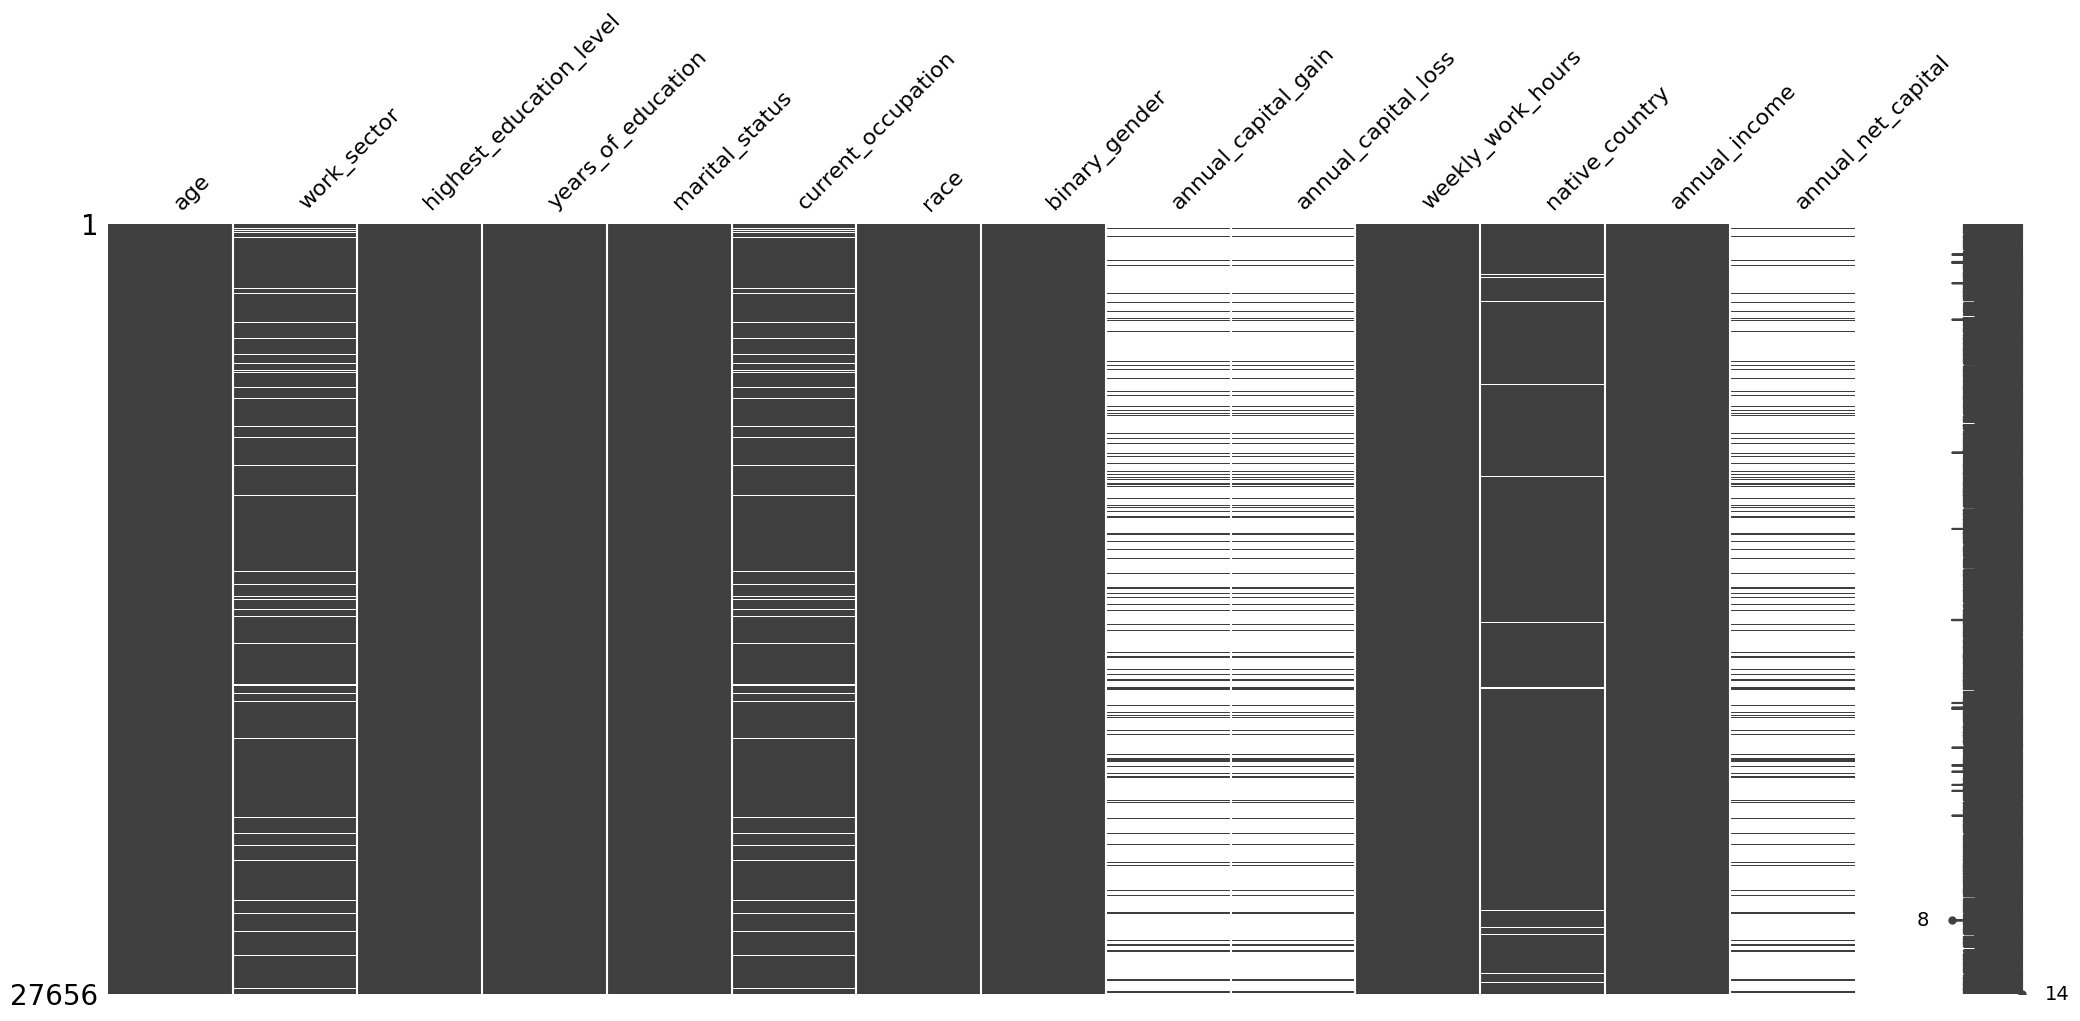

In [ ]:
msno.matrix(df_limpio)

In [ ]:
# en train
df_limpio.drop(columns=['annual_capital_gain', 'annual_capital_loss', 'annual_net_capital'], inplace=True)

# en test
df_test.drop(columns=['annual_capital_gain', 'annual_capital_loss', 'annual_net_capital'], inplace=True)

In [ ]:
mask_nulos_ws_o = df_limpio['work_sector'].isnull() | df_limpio['current_occupation'].isnull()
valores_unicos_en_nulos = pd.Series(dtype=object)

for col in df_limpio.columns:
    valores_unicos_en_nulos[col] = [val for val in df_limpio[mask_nulos_ws_o][col].unique().tolist() if val not in df_limpio[~mask_nulos_ws_o][col].unique().tolist()]

valores_unicos_en_nulos.name = 'Valores únicos con "work_sector" o "current_occupation" nulos'

In [ ]:
valores_unicos_en_nulos

,"Valores únicos con ""work_sector"" o ""current_occupation"" nulos"
age,[87]
work_sector,"[nan, Never-worked]"
highest_education_level,[]
years_of_education,[]
marital_status,[]
current_occupation,[nan]
race,[]
binary_gender,[]
weekly_work_hours,[]
native_country,[]


In [ ]:
mask_nulos_c = df_limpio['native_country'].isnull()
valores_unicos_en_nulos = pd.Series(dtype=object)

for col in df_limpio.columns:
    valores_unicos_en_nulos[col] = [val for val in df_limpio[mask_nulos_c][col].unique().tolist() if val not in df_limpio[~mask_nulos_c][col].unique().tolist()]

valores_unicos_en_nulos.name = 'Valores únicos con "native_country" nulo'

valores_unicos_en_nulos

,"Valores únicos con ""native_country"" nulo"
age,[]
work_sector,[]
highest_education_level,[]
years_of_education,[]
marital_status,[]
current_occupation,[]
race,[]
binary_gender,[]
weekly_work_hours,[]
native_country,[nan]


In [ ]:
df_limpio.loc[:, (df_limpio.isnull().sum() > 0).values].dtypes

,0
work_sector,object
current_occupation,object
native_country,object


In [ ]:
# en train
sp_mode = SimpleImputer(strategy='most_frequent')

sp_mode.fit(df_limpio[['work_sector', 'current_occupation', 'native_country']])
df_limpio[['work_sector', 'current_occupation', 'native_country']] = sp_mode.transform(df_limpio[['work_sector', 'current_occupation', 'native_country']])

# en test
sp_mode = SimpleImputer(strategy='most_frequent')

sp_mode.fit(df_test[['work_sector', 'current_occupation', 'native_country']])
df_test[['work_sector', 'current_occupation', 'native_country']] = sp_mode.transform(df_test[['work_sector', 'current_occupation', 'native_country']])

Metadatos de las columnas:

| Nombre original        | Nuevo nombre              | Tipo de dato por defecto |
|------------------------|---------------------------|---------------------------|
| age                    | age                       | int64                    |
| workclass              | work_sector               | object                   |
| education              | highest_education_level   | object                   |
| education.num          | years_of_education        | int64                    |
| marital.status         | marital_status            | object                   |
| occupation             | current_occupation        | object                   |
| relationship           | marital_relationship      | object                   |
| race                   | race                      | object                   |
| sex                    | binary_gender             | object                   |
| capital.gain           | annual_capital_gain       | int64                    |
| capital.loss           | annual_capital_loss       | int64                    |
| hours.per.week         | weekly_work_hours         | int64                    |
| native.country         | native_country            | object                   |
| income                 | annual_income             | object                   |
|                        | annual_net_capital        | int64 |

---

## Exploración univariable

### Exploración de columnas categoricas:

In [ ]:
columnas_categoricas = df_limpio.select_dtypes(include=['object', 'category']).columns

#### Frecuencia de categorias unicas

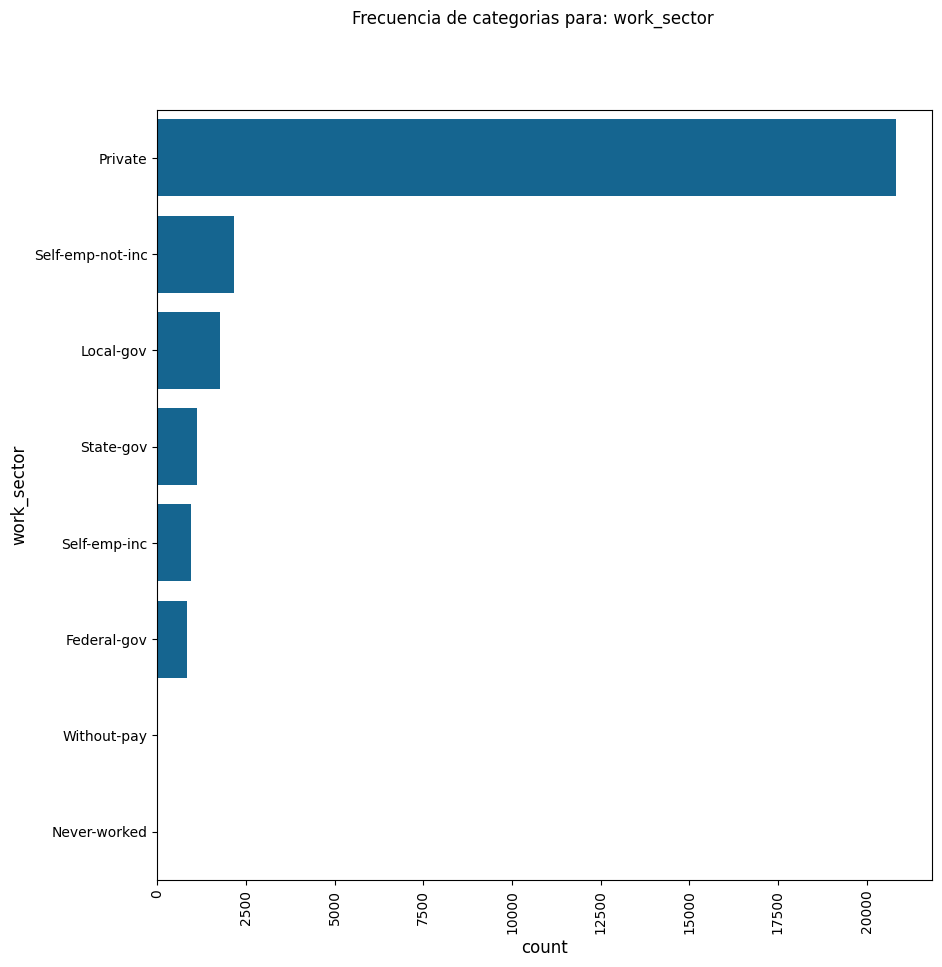

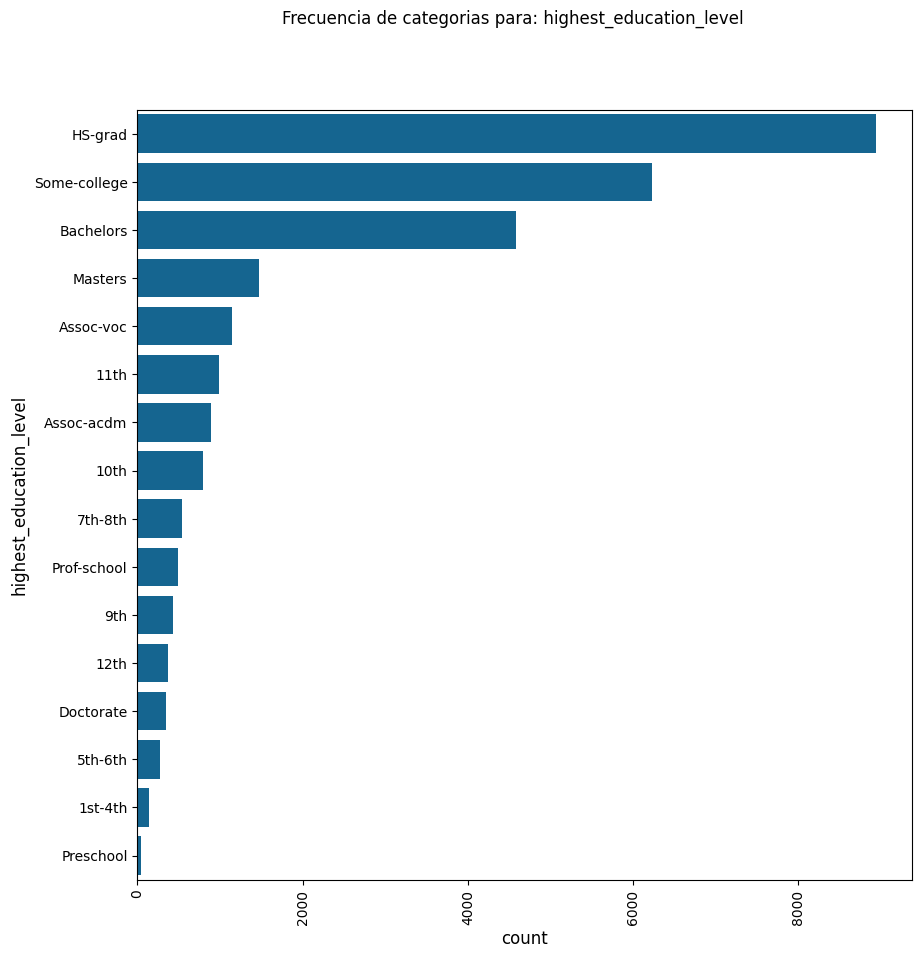

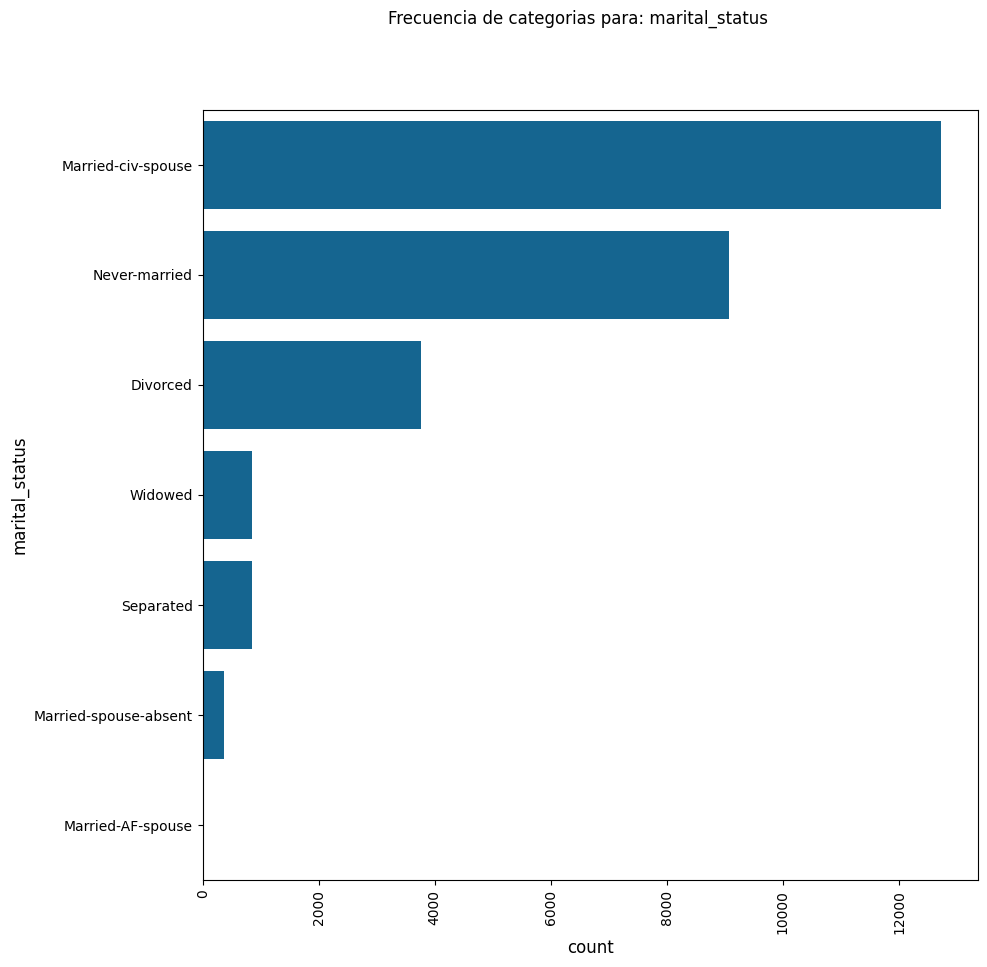

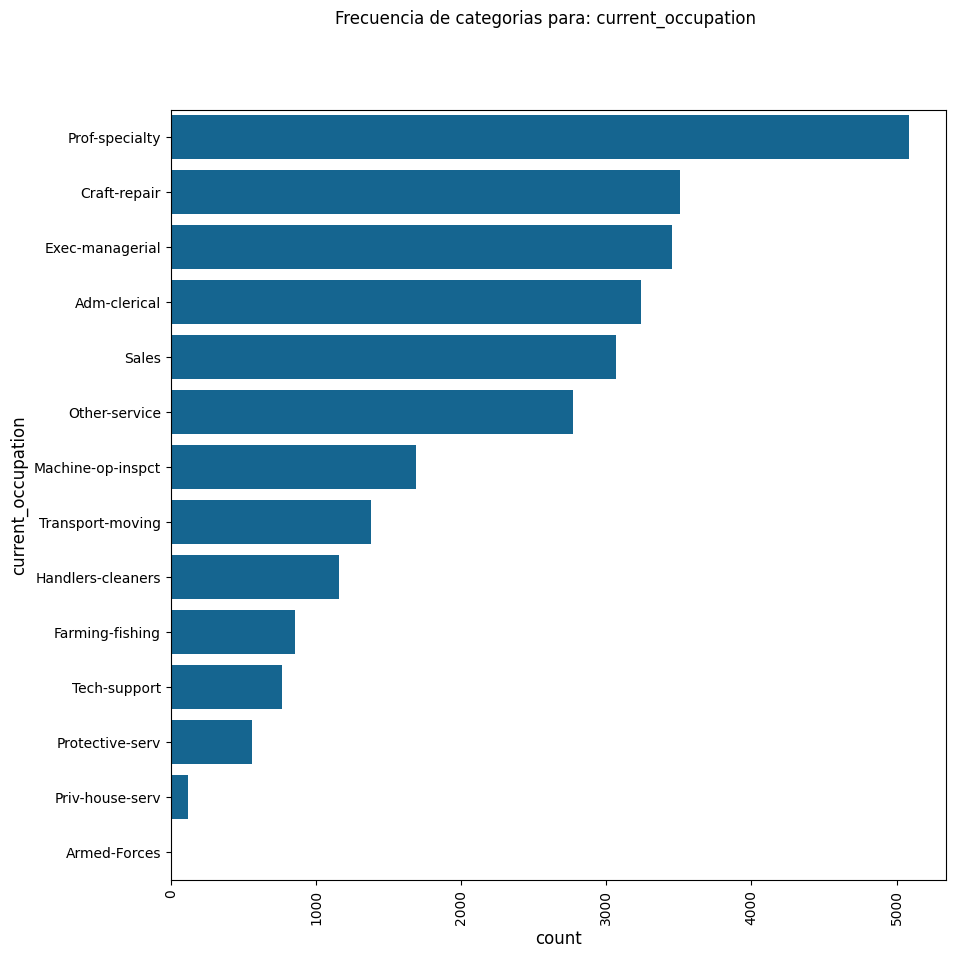

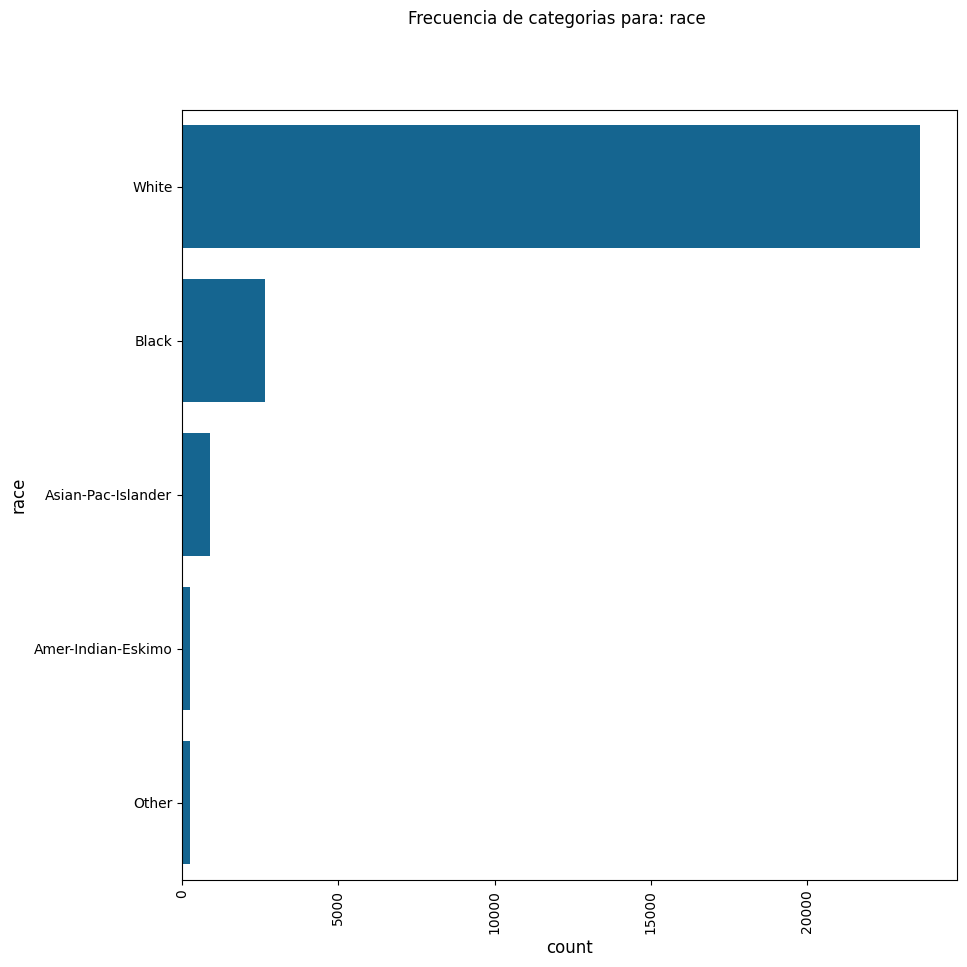

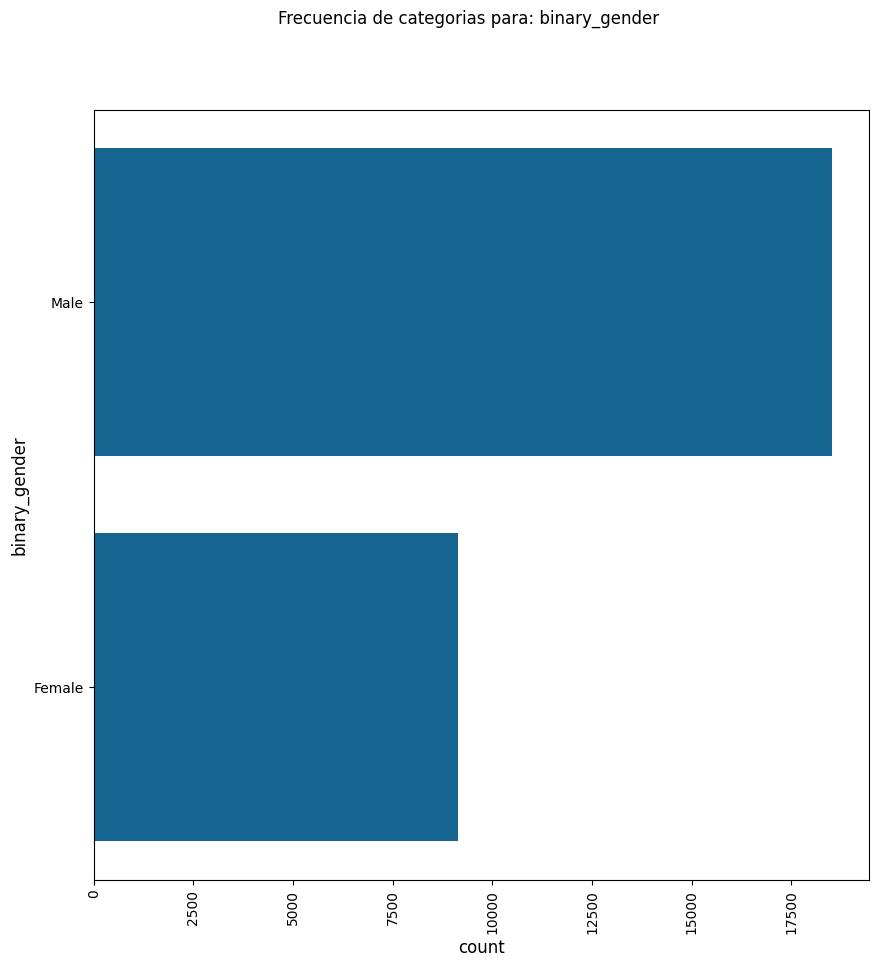

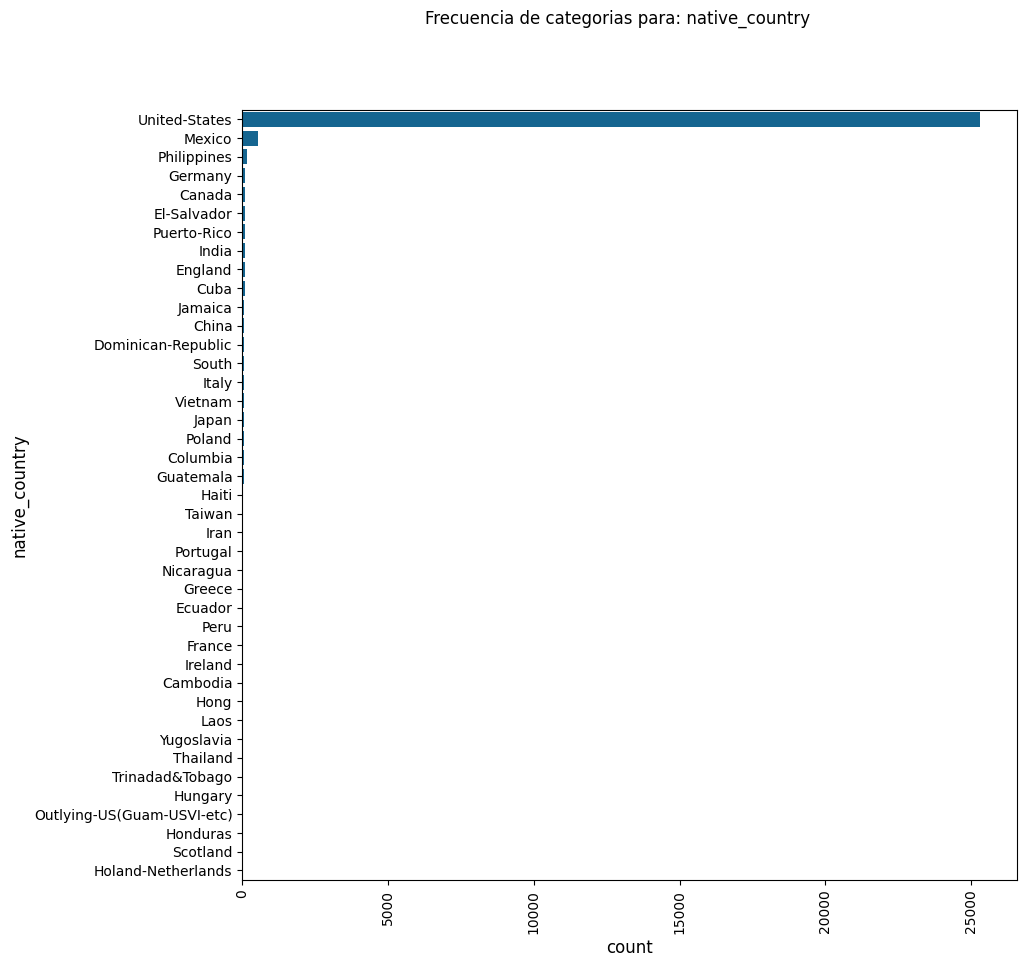

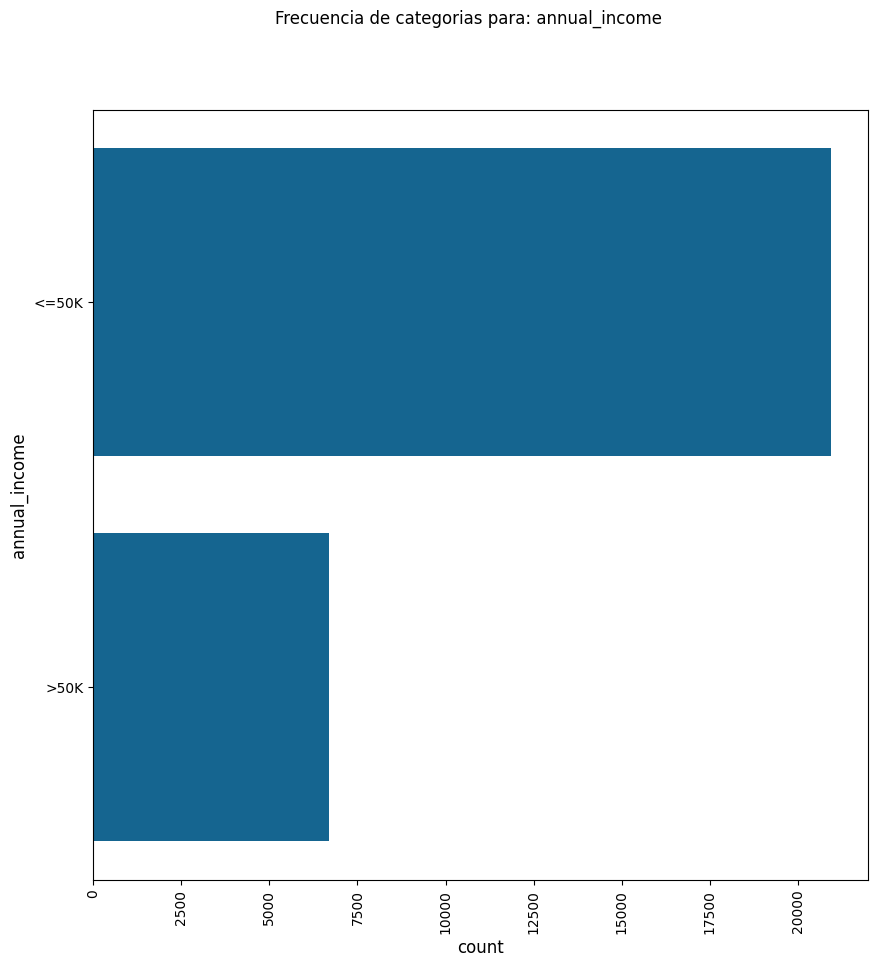

In [ ]:
for obj_column in columnas_categoricas:
  plt.suptitle(t=f'Frecuencia de categorias para: {obj_column}')

  orden = df_limpio[obj_column].value_counts().index

  # grafico de barras
  sns.countplot(data=df_limpio[obj_column], order=orden)
  plt.xticks(rotation=90)
  plt.show()
  print()

In [ ]:
# en train
mask_ws = df_limpio['work_sector'].isin(['Never-worked', 'Without-pay'])
df_limpio.loc[mask_ws, 'work_sector'] = 'not_working'

# en test
mask_ws = df_test['work_sector'].isin(['Never-worked', 'Without-pay'])
df_test.loc[mask_ws, 'work_sector'] = 'not_working'

In [ ]:
# en train
mask_country = df_limpio['native_country'] != 'United-States'
df_limpio.loc[mask_country, 'native_country'] = 'other_country'

# en test
mask_country = df_test['native_country'] != 'United-States'
df_test.loc[mask_country, 'native_country'] = 'other_country'

In [ ]:
# en train
mask_he_unfinished = df_limpio['highest_education_level'].isin(["11th", "9th", "7th-8th", "5th-6th", "10th", "1st-4th", "12th", "Preschool"])
df_limpio.loc[mask_he_unfinished, 'highest_education_level'] = 'unfinished'

# en test
mask_he_unfinished = df_test['highest_education_level'].isin(["11th", "9th", "7th-8th", "5th-6th", "10th", "1st-4th", "12th", "Preschool"])
df_test.loc[mask_he_unfinished, 'highest_education_level'] = 'unfinished'

In [ ]:
# en train
df_limpio[columnas_categoricas] = df_limpio[columnas_categoricas].astype('category')

# en test
df_test[columnas_categoricas.drop('annual_income')] = df_test[columnas_categoricas.drop('annual_income')].astype('category')

#### Observaciones de la etapa


- **Frecuencias de observaciones:**
  - Las clases de la columna target presentan desbalanceo, se considerara a la hora de hacer el split.
    - `<=50K`:	20946
    - `>50K`:	6703
  - La mayorias de columnas precentan categoprias con frecuencias desbalanceadas.
  - En general la cantidad de categorias por filas pueden ser manejadas por OneHotEnoder ya que no son tantas, exceptuando pais, a la cual se elegiran las observaciones hasta Guatemala en orden desendente desde la mayor a la de menor frecuencia para no aumentar inecesariamente la dimensionalidad del conjunto de datos.



### Exploración de columnas numéricas:

In [ ]:
columnas_numericas = df_limpio.select_dtypes(include='number').columns

#### Estadisticas descriptivas

In [ ]:
# estadisticas sobre columnas numericas
df_limpio.describe()

,age,years_of_education,weekly_work_hours
count,27656.00,27656.00,27656.00
mean,38.61,10.09,40.45
std,13.66,2.57,12.37
min,17.00,1.00,1.00
25%,28.00,9.00,40.00
50%,37.00,10.00,40.00
75%,48.00,12.00,45.00
max,90.00,16.00,99.00


#### Distribuciones y valores atipicos

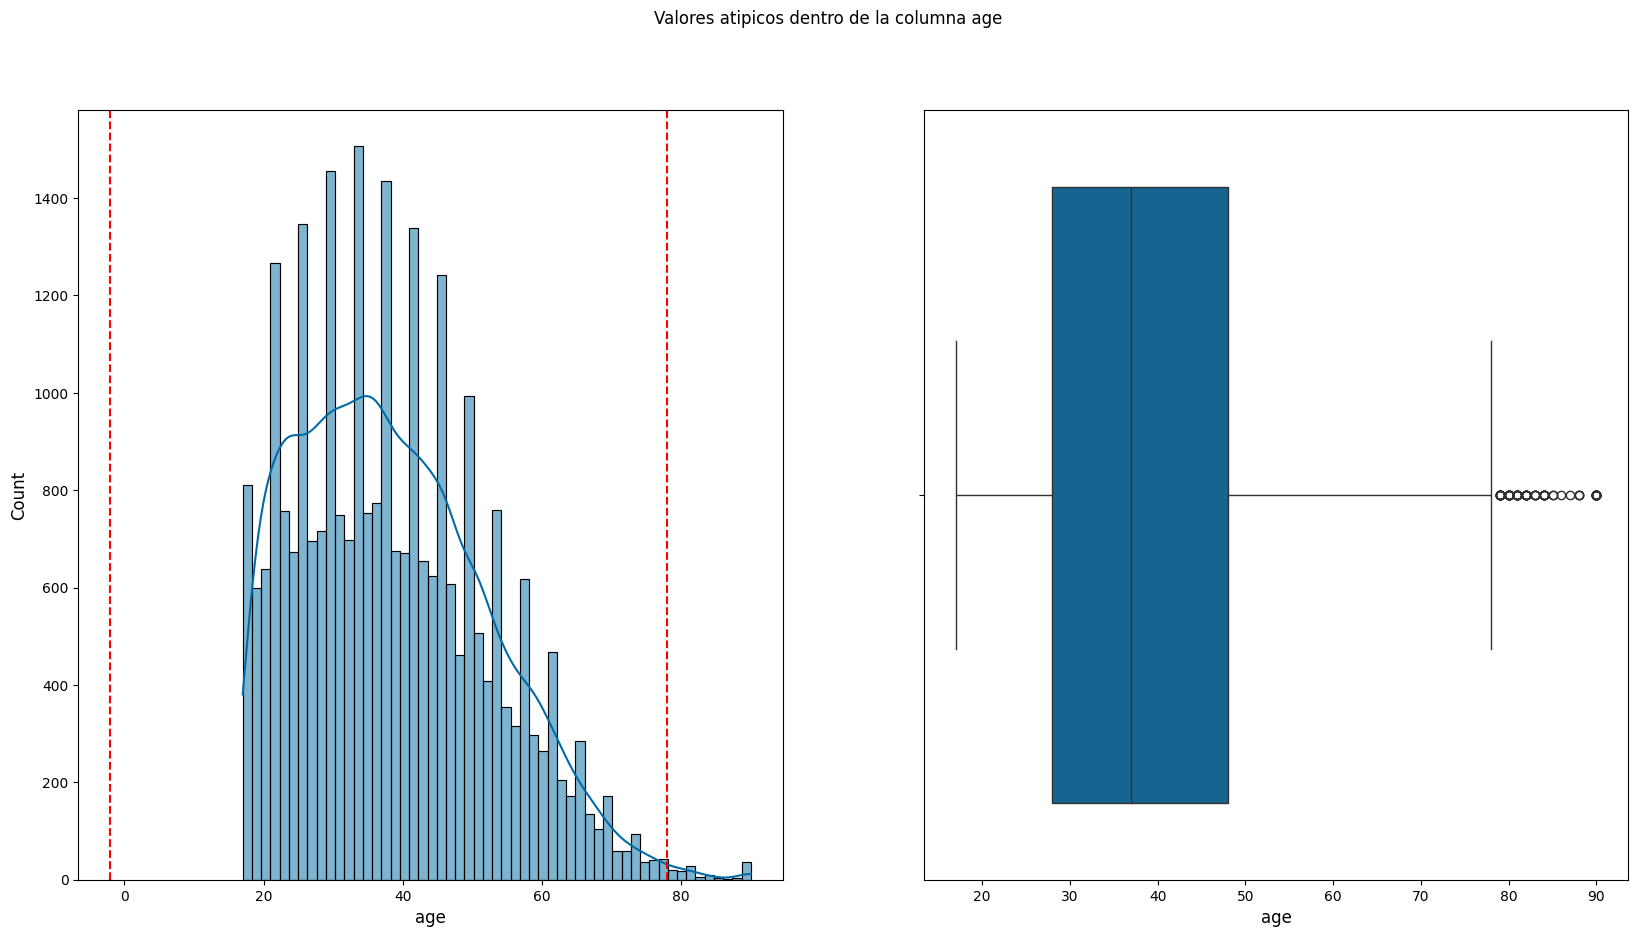

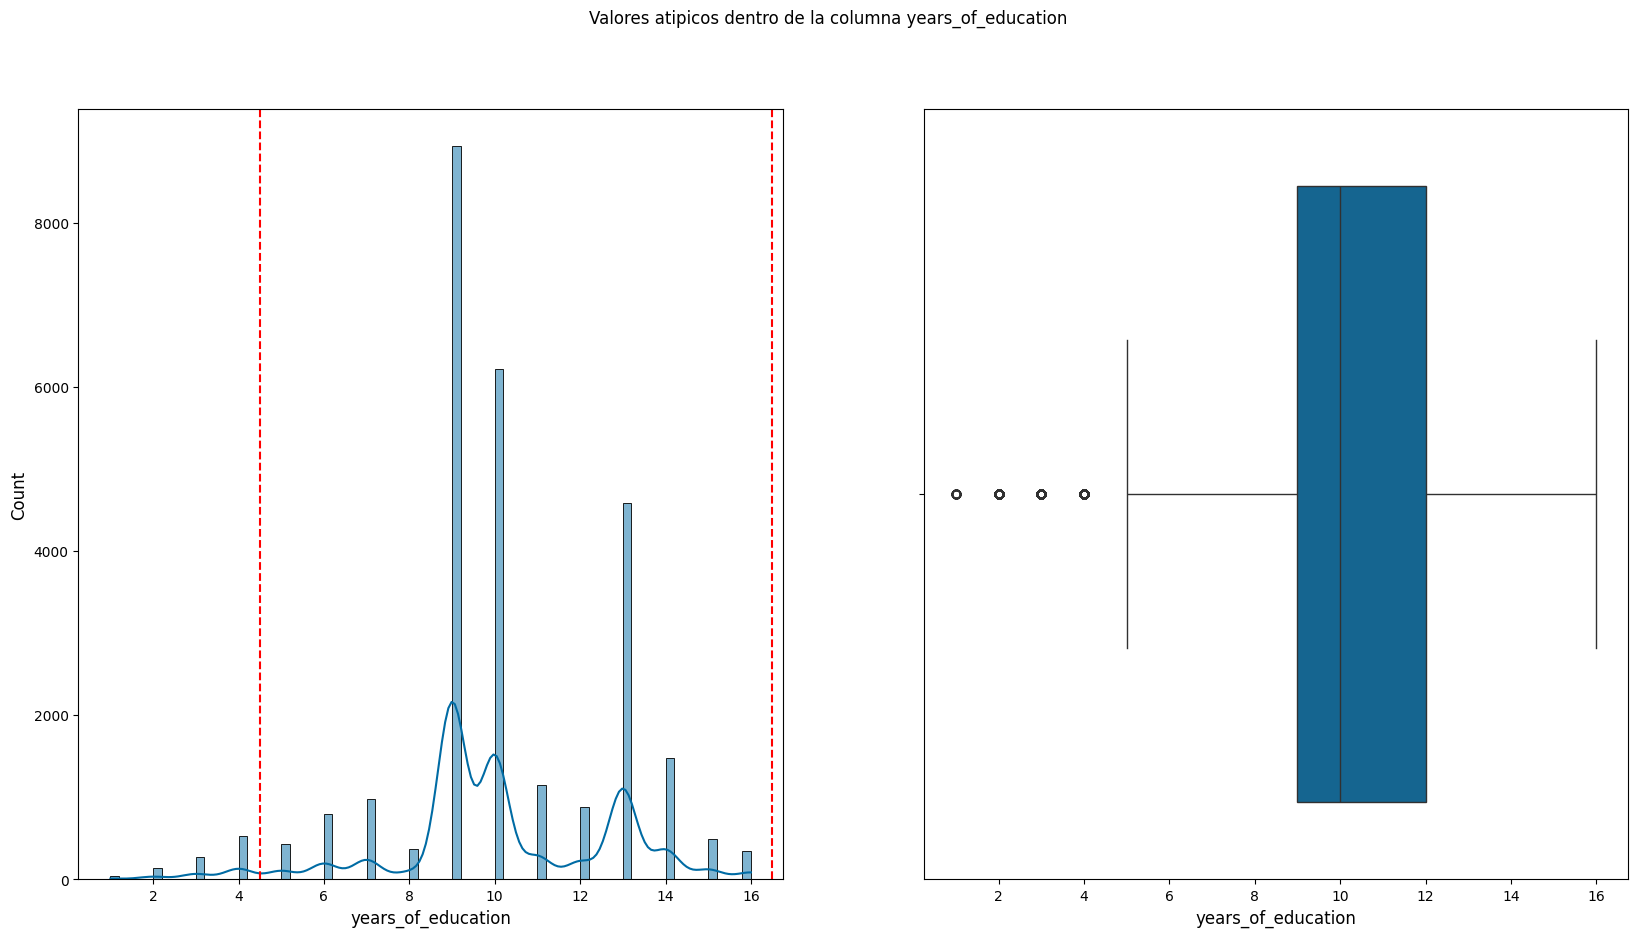

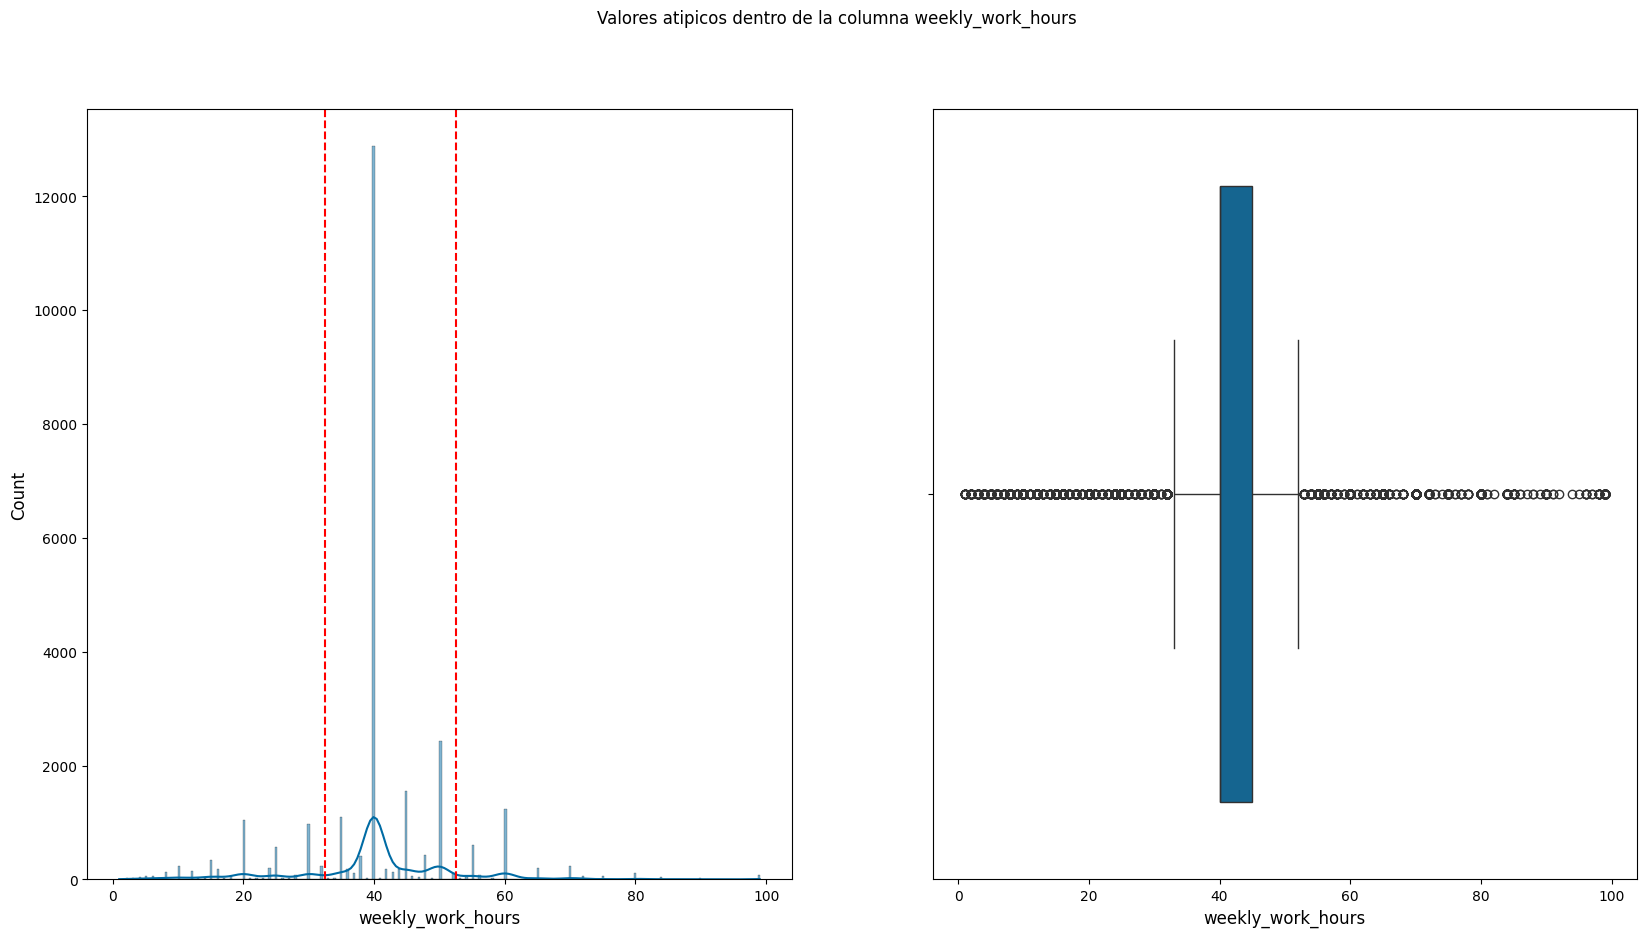

In [ ]:
for nombre_col in columnas_numericas:
  limites_outliers = limite_outliers(df=df_limpio, column=nombre_col)

  fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20, 10))
  plt.suptitle(t=f'Valores atipicos dentro de la columna {nombre_col}')

  # grafico kde
  c_bins_lp = bins_calculator_fd(df=df_limpio, column=nombre_col)
  sns.histplot(data=df_limpio, x=nombre_col, kde=True, bins=c_bins_lp, ax=ax[0])
  ax[0].axvline(x=limites_outliers['limite_inferior'], c='red', linestyle='dashed')
  ax[0].axvline(x=limites_outliers['limite_superior'], c='red', linestyle='dashed')

  # grafico de caja
  sns.boxplot(data=df_limpio, x=nombre_col, ax=ax[1])

  plt.show()

  print()

#### Observaciones de la etapa

- **Distribución:** No se observa una distribución completamente normal en ninguno de los casos, la mas cercana a este tipo de distribuciones es `weekly_work_hours`, pero aun hay precenscia de valores atipicos en su extremo derecho, que probablemente sean representativos del conjunito de datos. posiblemente halla que aplicar RobustScaler como escalador.


- **Outliers o valores atipicos:** Se ven varios valores atipicos a lo largo de la mayoria de las distribuciones, pero en ningun caso son valores totalmente ilogicos para  de cada una de las columnas numericas que representa. En la secciónde exploración bivariable, pondremos mayor foco en analizar dichos valores en comparación con otras variables.



---

## Analisis bivariable

Puede que estas estadisticas esten influenciadas por las diferentes clases de la columna target?

In [ ]:
# groupby por especie mas describe
df_limpio.groupby(by=['annual_income'], as_index=False).describe()

<ipython-input-44-383ba8b83522>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_limpio.groupby(by=['annual_income'], as_index=False).describe()


annual_income      age                                           years_of_education                              \
                   count  mean   std   min   25%   50%   75%   max              count  mean  std  min   25%   50%   
0         <=50K 20953.00 36.79 14.04 17.00 25.00 34.00 46.00 90.00           20953.00  9.60 2.43 1.00  9.00  9.00   
1          >50K  6703.00 44.29 10.52 19.00 36.00 44.00 51.00 90.00            6703.00 11.63 2.36 2.00 10.00 13.00   

              weekly_work_hours                                           
    75%   max             count  mean   std  min   25%   50%   75%   max  
0 10.00 16.00          20953.00 38.85 12.34 1.00 35.00 40.00 40.00 99.00  
1 13.00 16.00           6703.00 45.44 11.06 1.00 40.00 40.00 50.00 99.00

In [ ]:
# df para 'annual_income' <=50K
mask_hue_menor_50 = df_limpio['annual_income'] == '<=50K'
df_limpio_menor_50 = df_limpio[mask_hue_menor_50]

In [ ]:
# df para 'annual_income' >50K
mask_hue_mayor_50 = df_limpio['annual_income'] == '>50K'
df_limpio_mayor_50 = df_limpio[mask_hue_mayor_50]

#### Columnas Categoricas

In [ ]:
columnas_categoricas = df_limpio.select_dtypes(include=['object', 'category']).columns.drop('annual_income')

##### Countplots de frecuencia por categorias

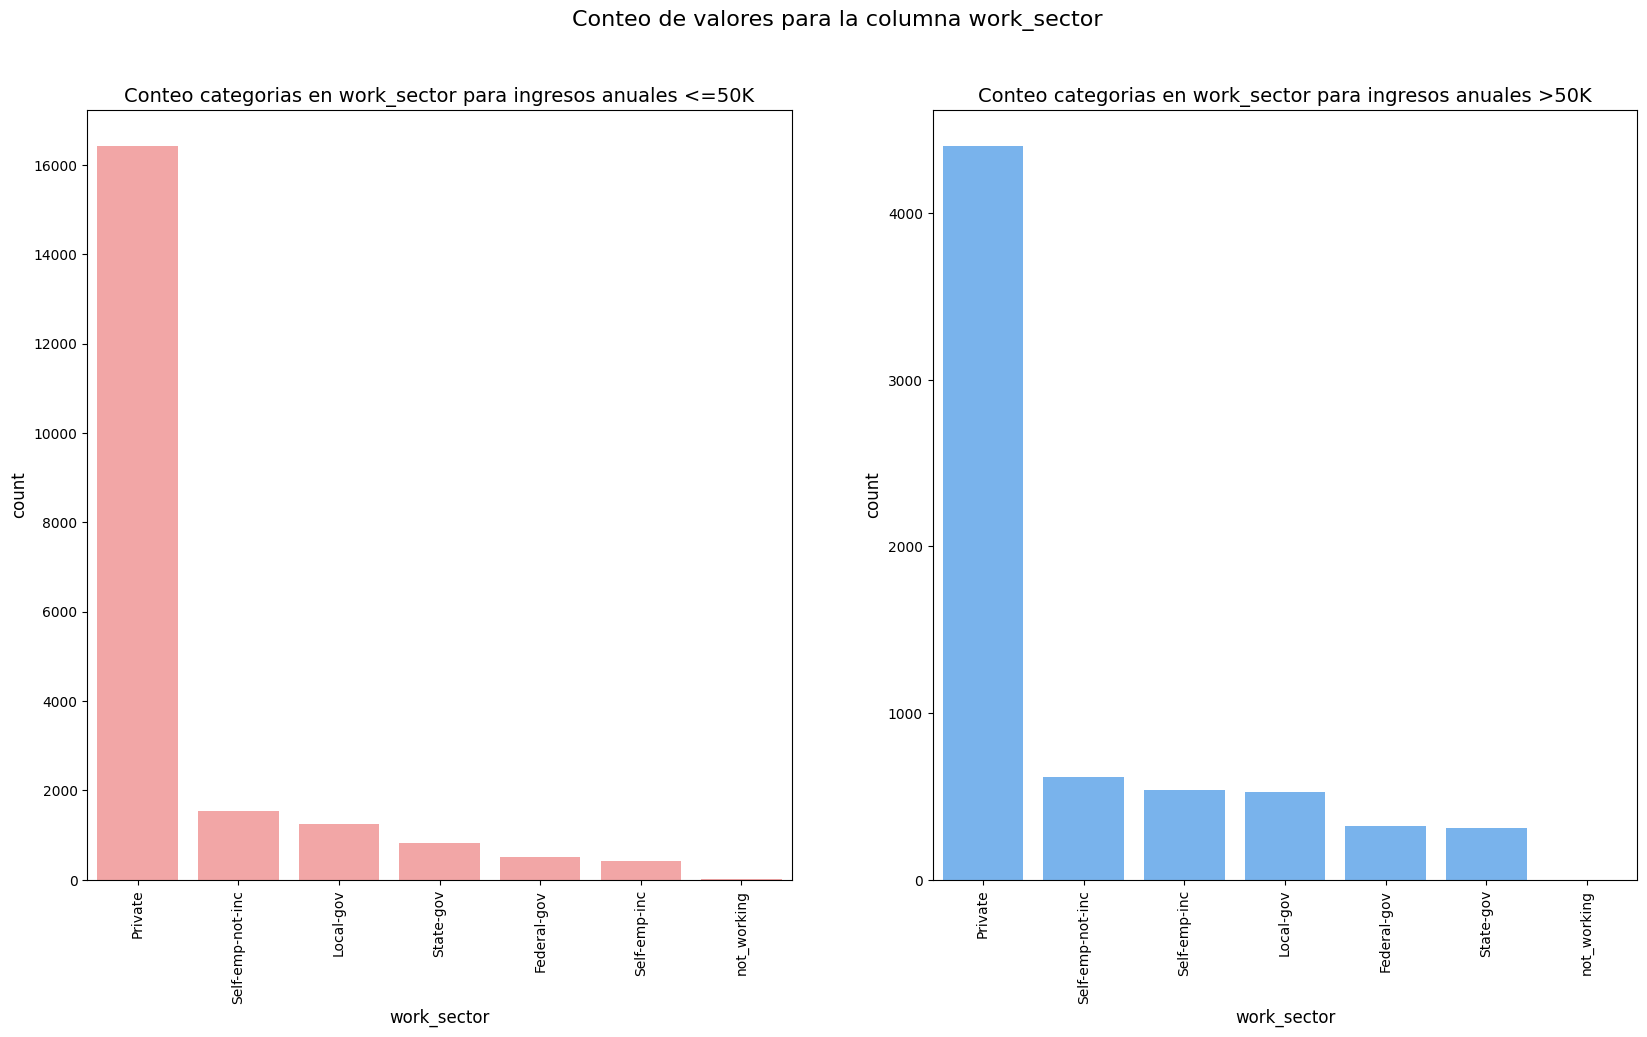

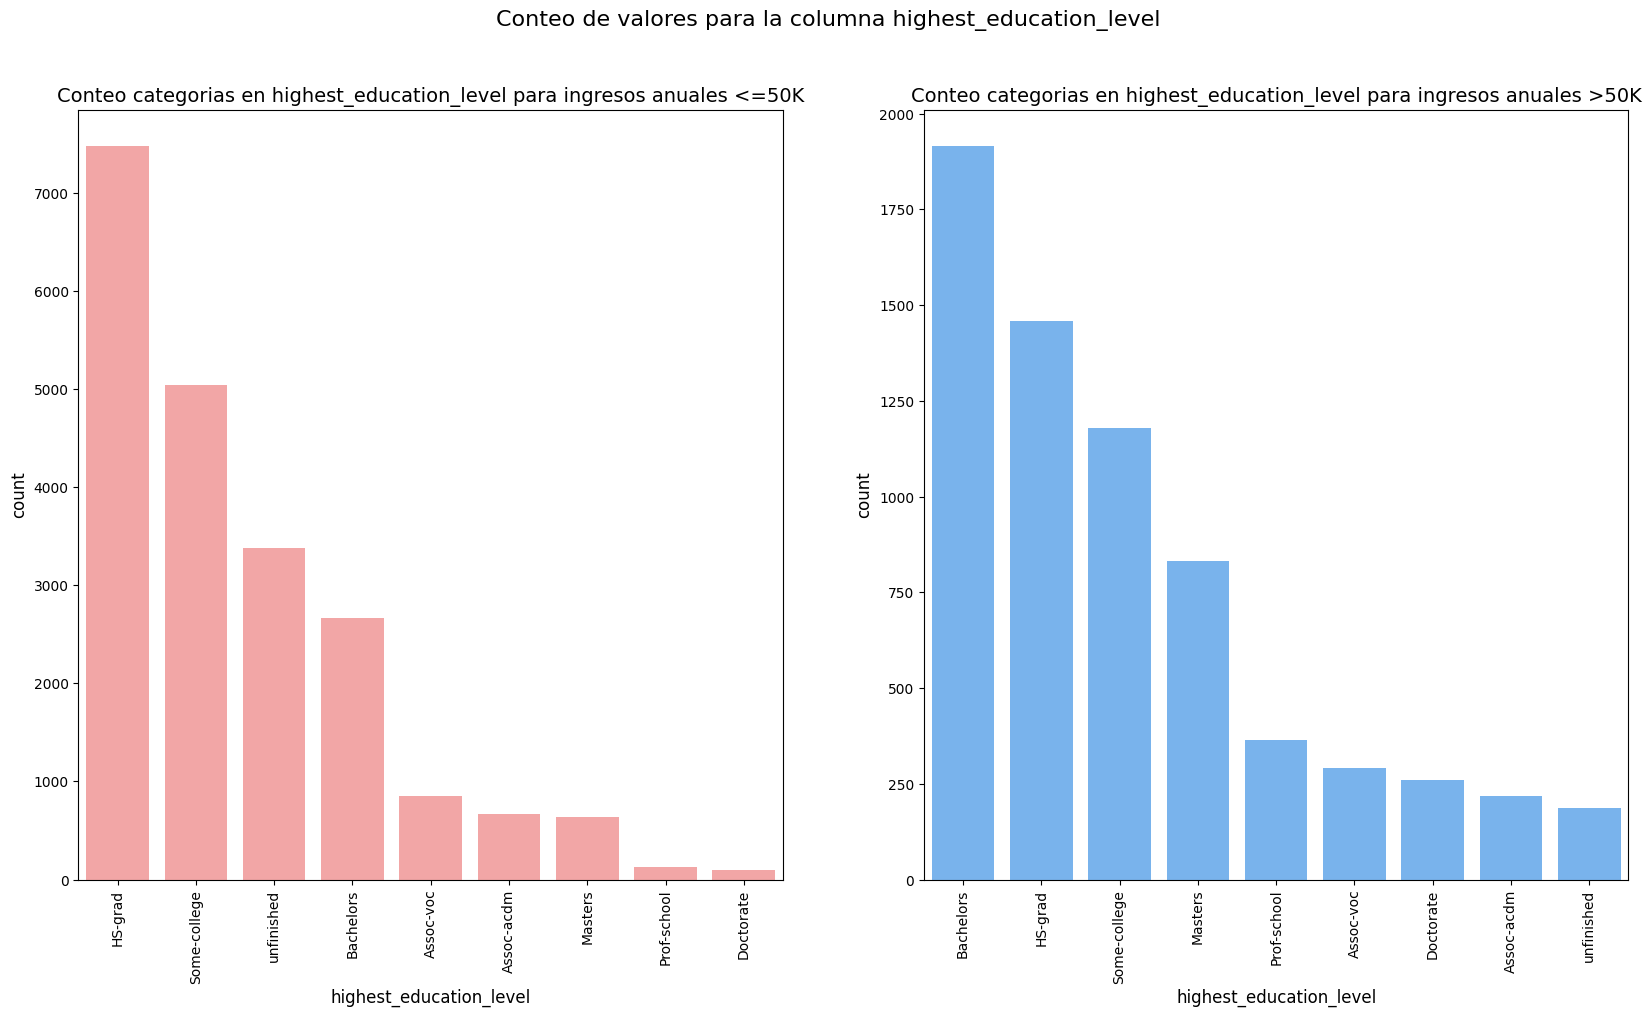

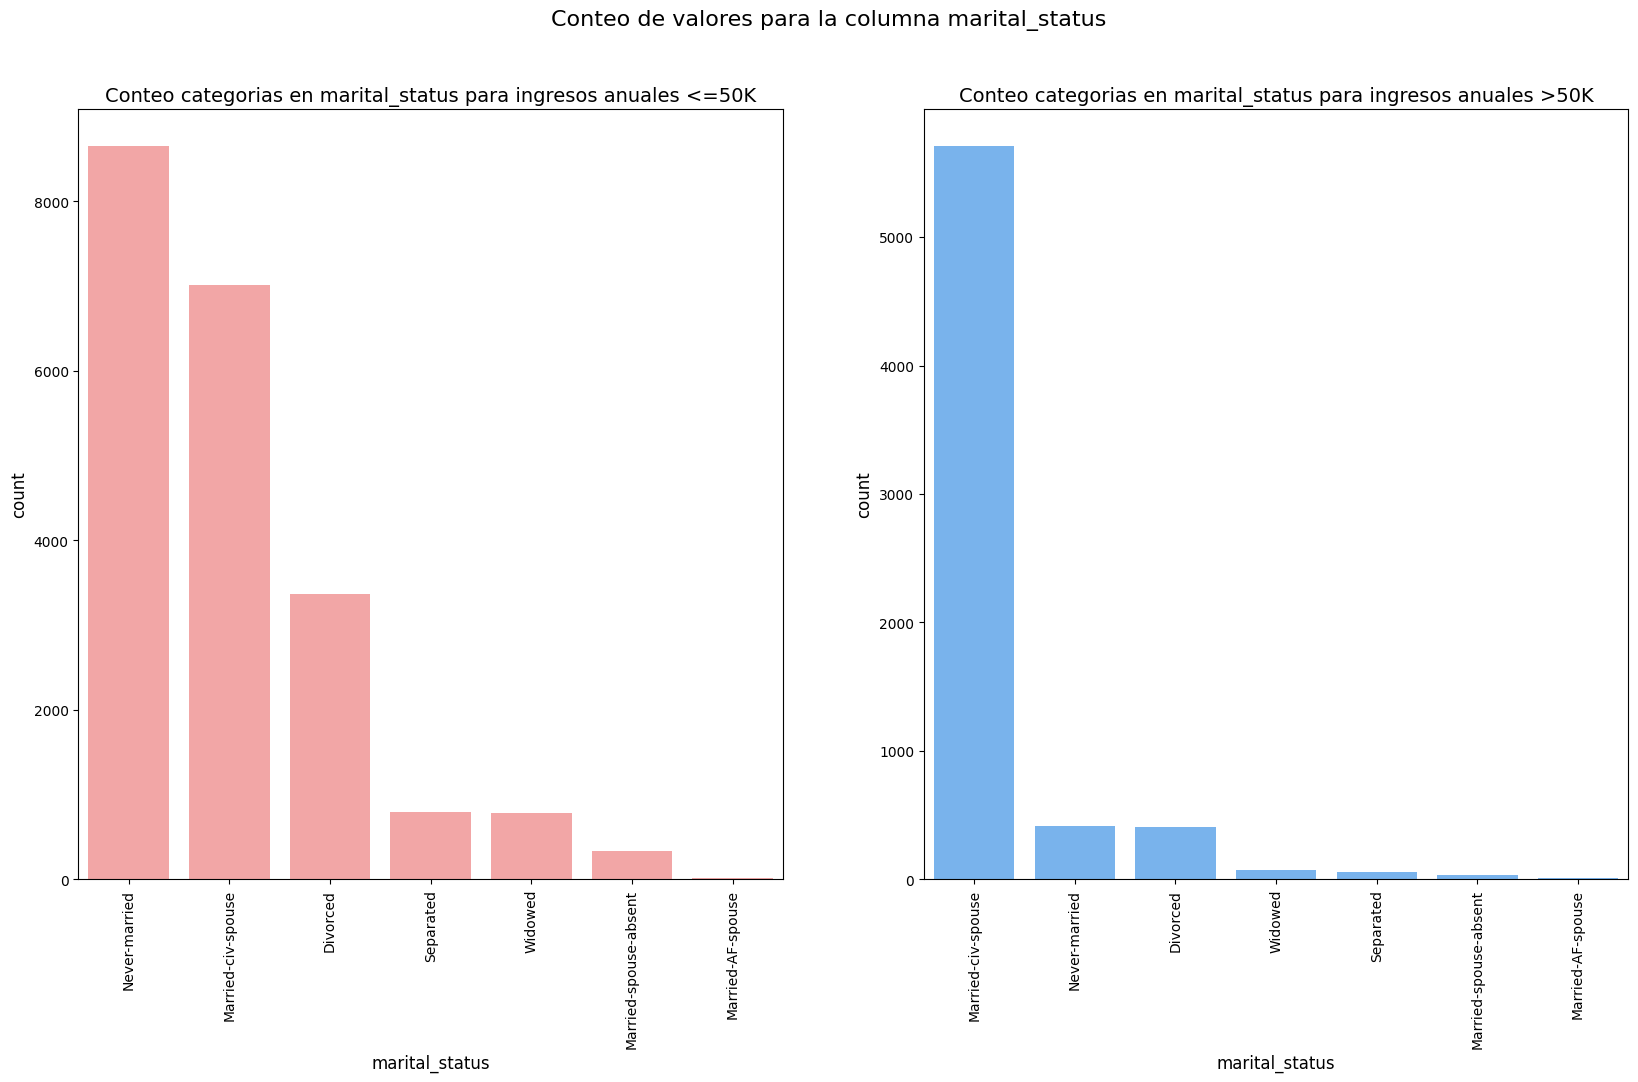

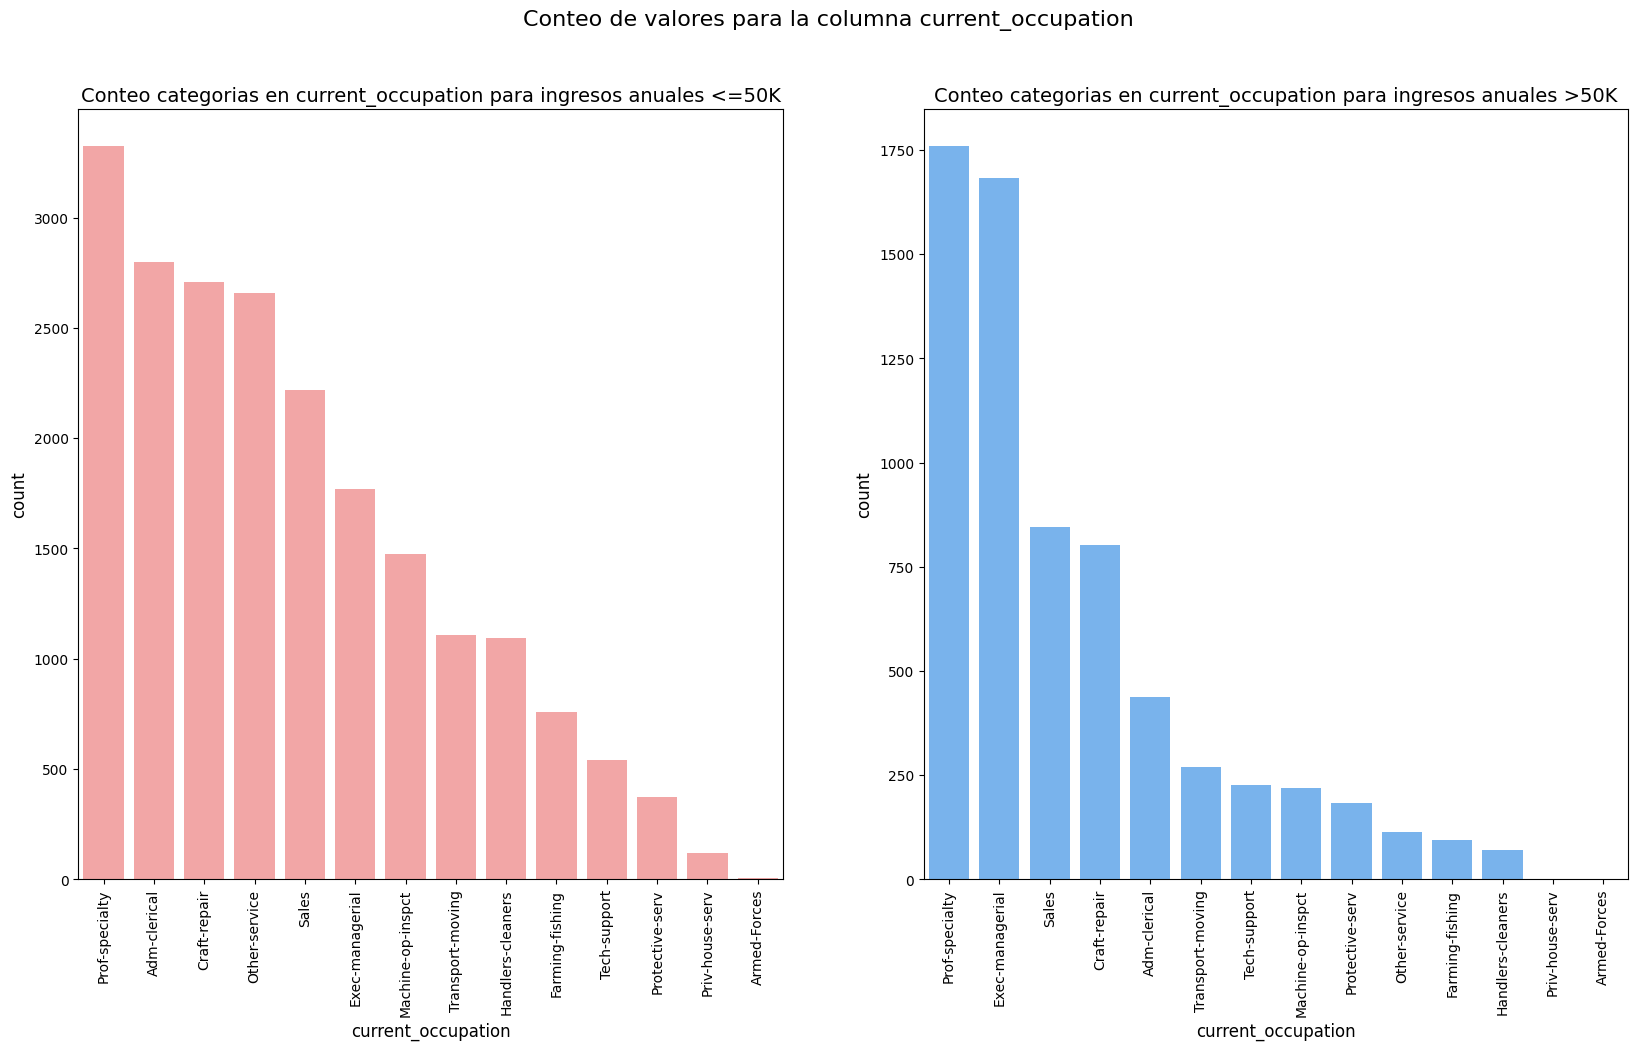

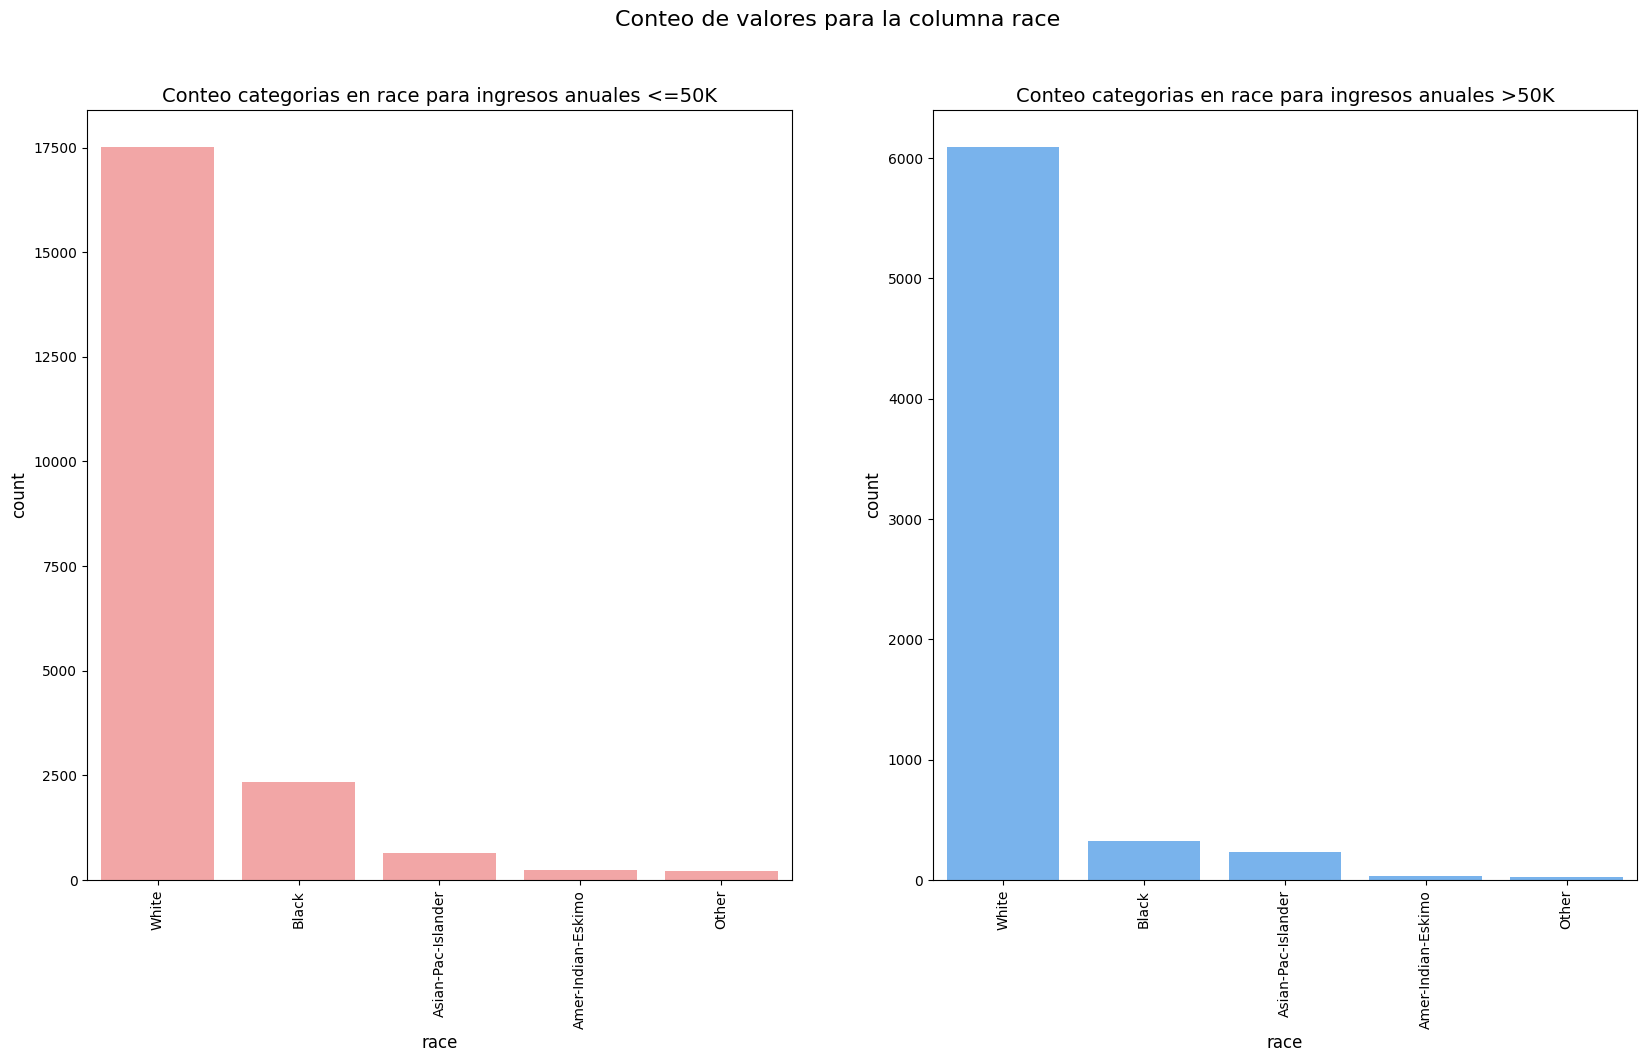

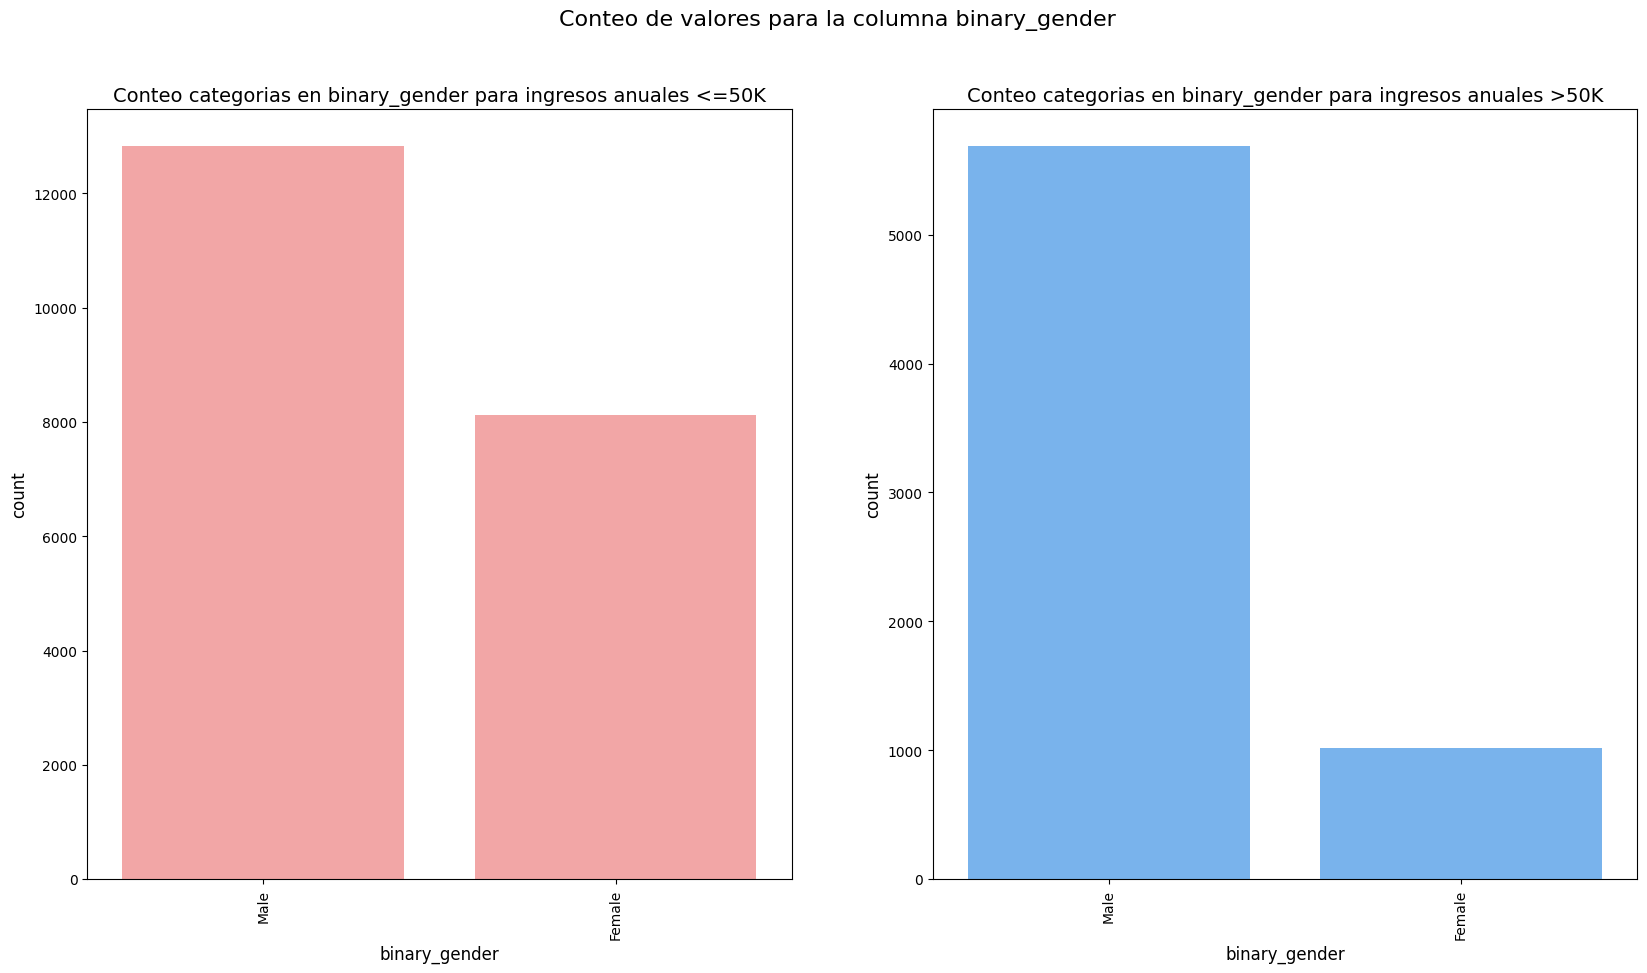

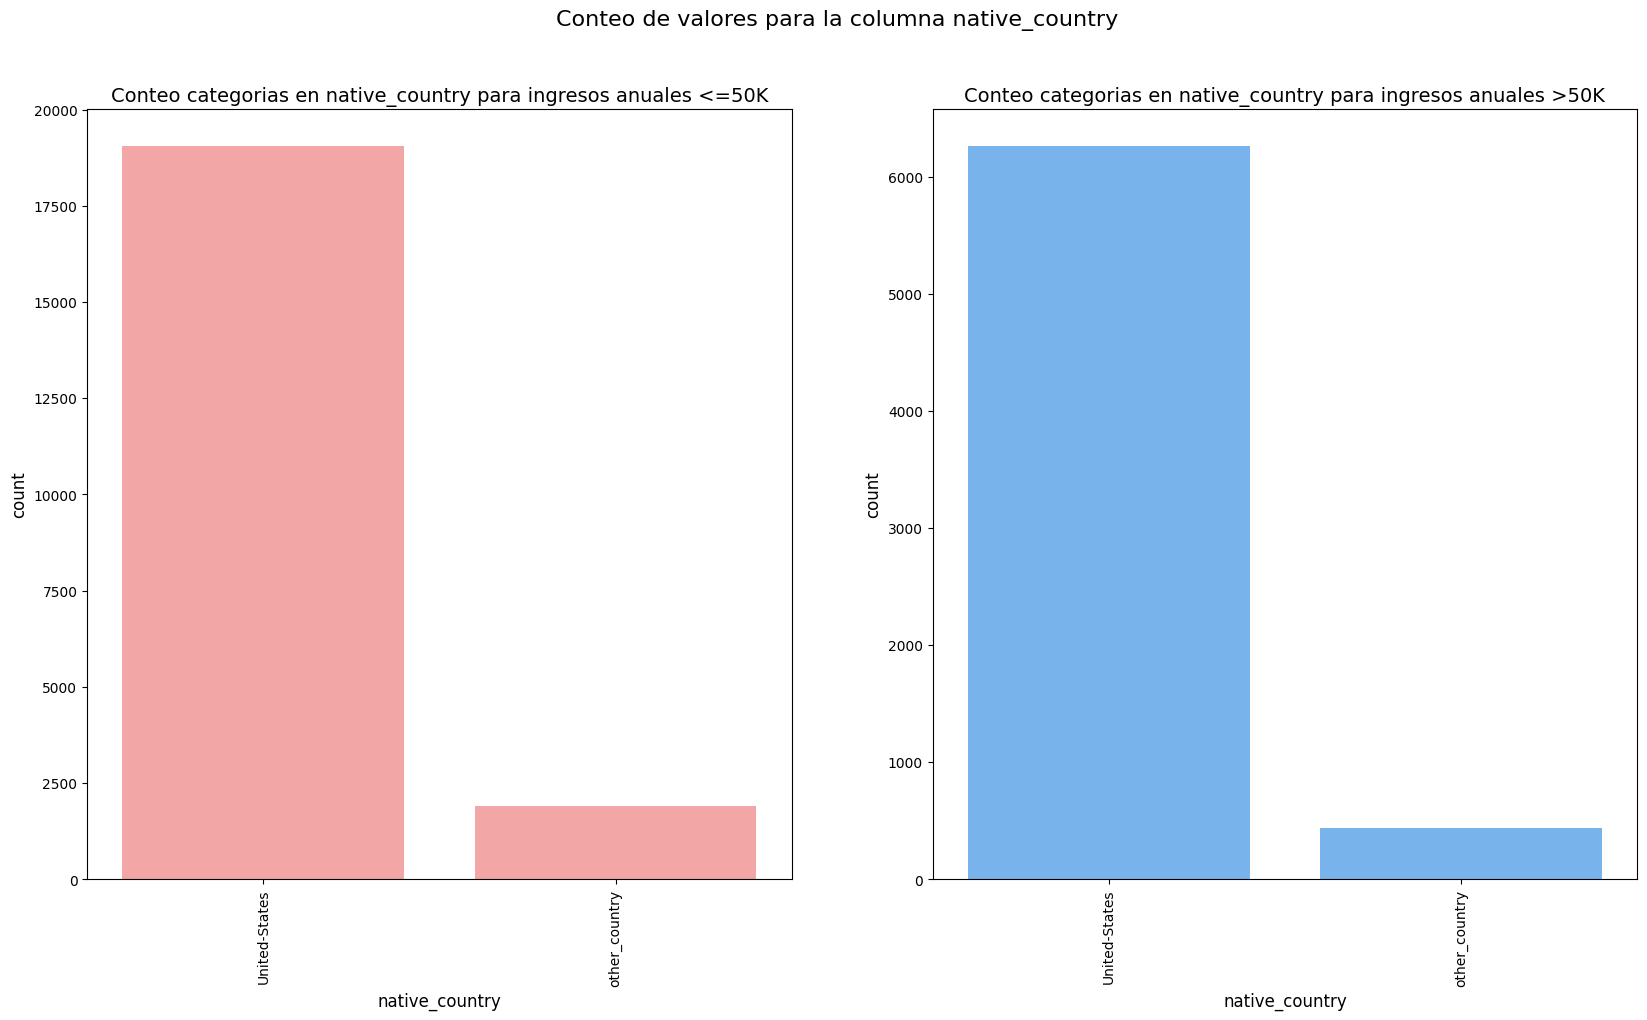

In [ ]:
for nombre_col in columnas_categoricas:
  fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20, 10))
  plt.suptitle(t=f'Conteo de valores para la columna {nombre_col}', fontsize=16, color='black')

  orden = df_limpio_menor_50[nombre_col].value_counts().index
  sns.countplot(data=df_limpio_menor_50, x=nombre_col, ax=ax[0], color=colores_income_annual['<=50K'], order=orden)
  ax[0].set_title(f'Conteo categorias en {nombre_col} para ingresos anuales <=50K')
  ax[0].tick_params(axis='x', rotation=90)

  orden = df_limpio_mayor_50[nombre_col].value_counts().index
  sns.countplot(data=df_limpio_mayor_50, x=nombre_col, ax=ax[1], color=colores_income_annual['>50K'], order=orden)
  ax[1].set_title(f'Conteo categorias en {nombre_col} para ingresos anuales >50K')
  ax[1].tick_params(axis='x', rotation=90)

  plt.show()

  print()

##### Observaciones de la etapa

- En general se mantienen las proporciones entre clases, solo se nota un aumento notorio en la columna de `binary_geder` donde se puede aprenciar cierta relacion lineal, para la clase `>50K` de la columna target, hay un aumento considerables en la proporcion de hombre frente a la proporcion em la otra clase de la misma columna target.

#### Columnas numericas

##### Valores atipicos

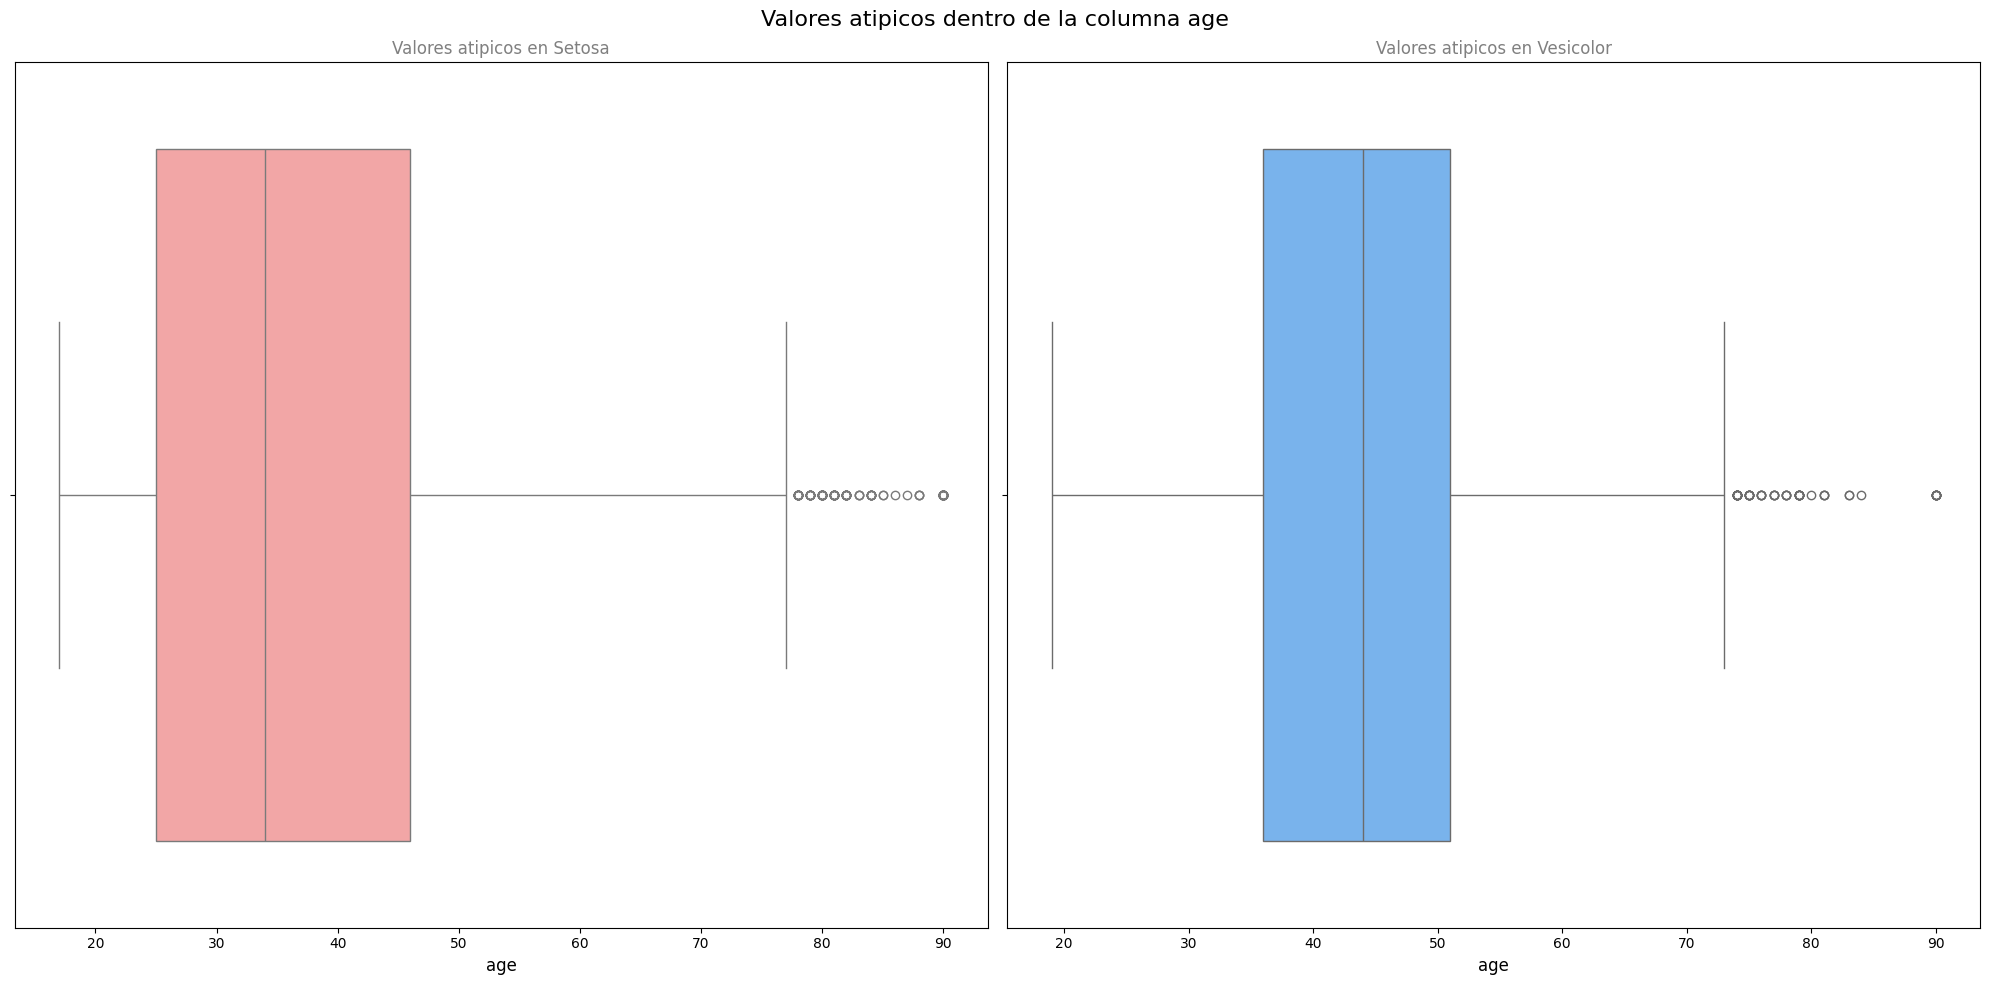

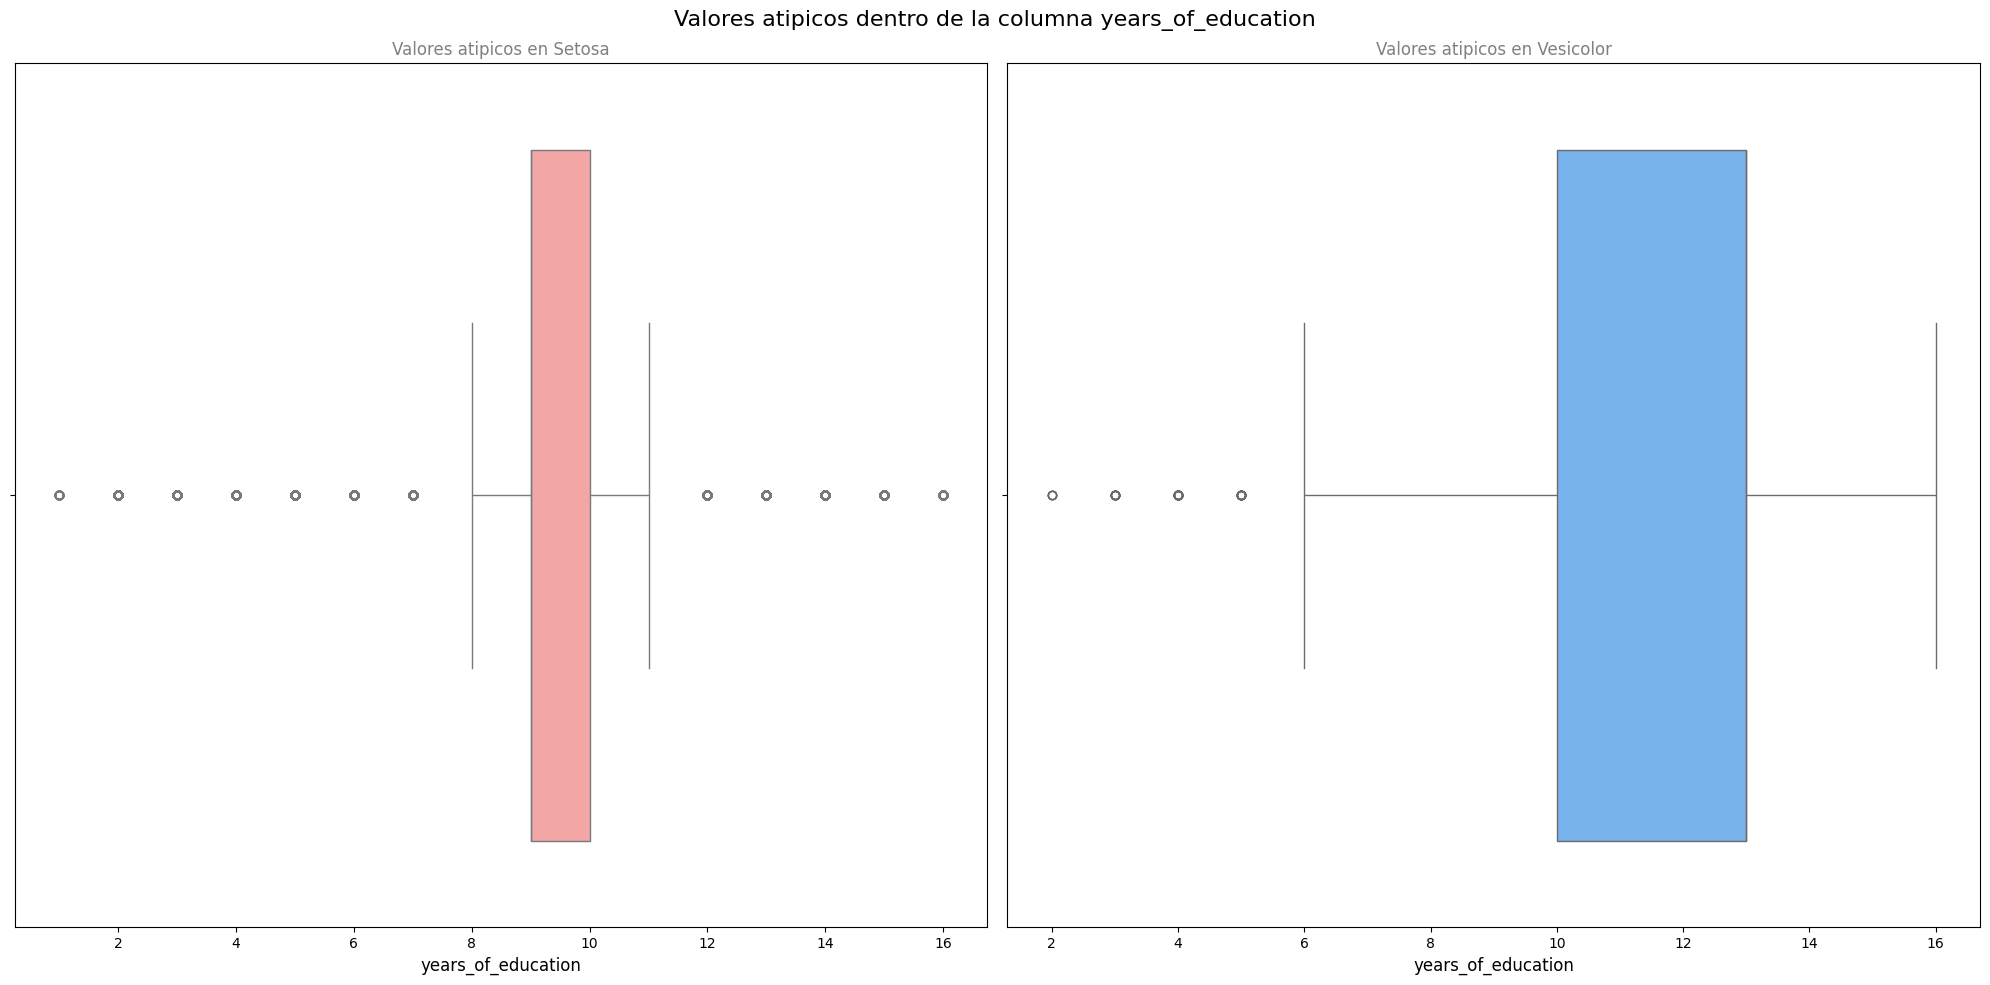

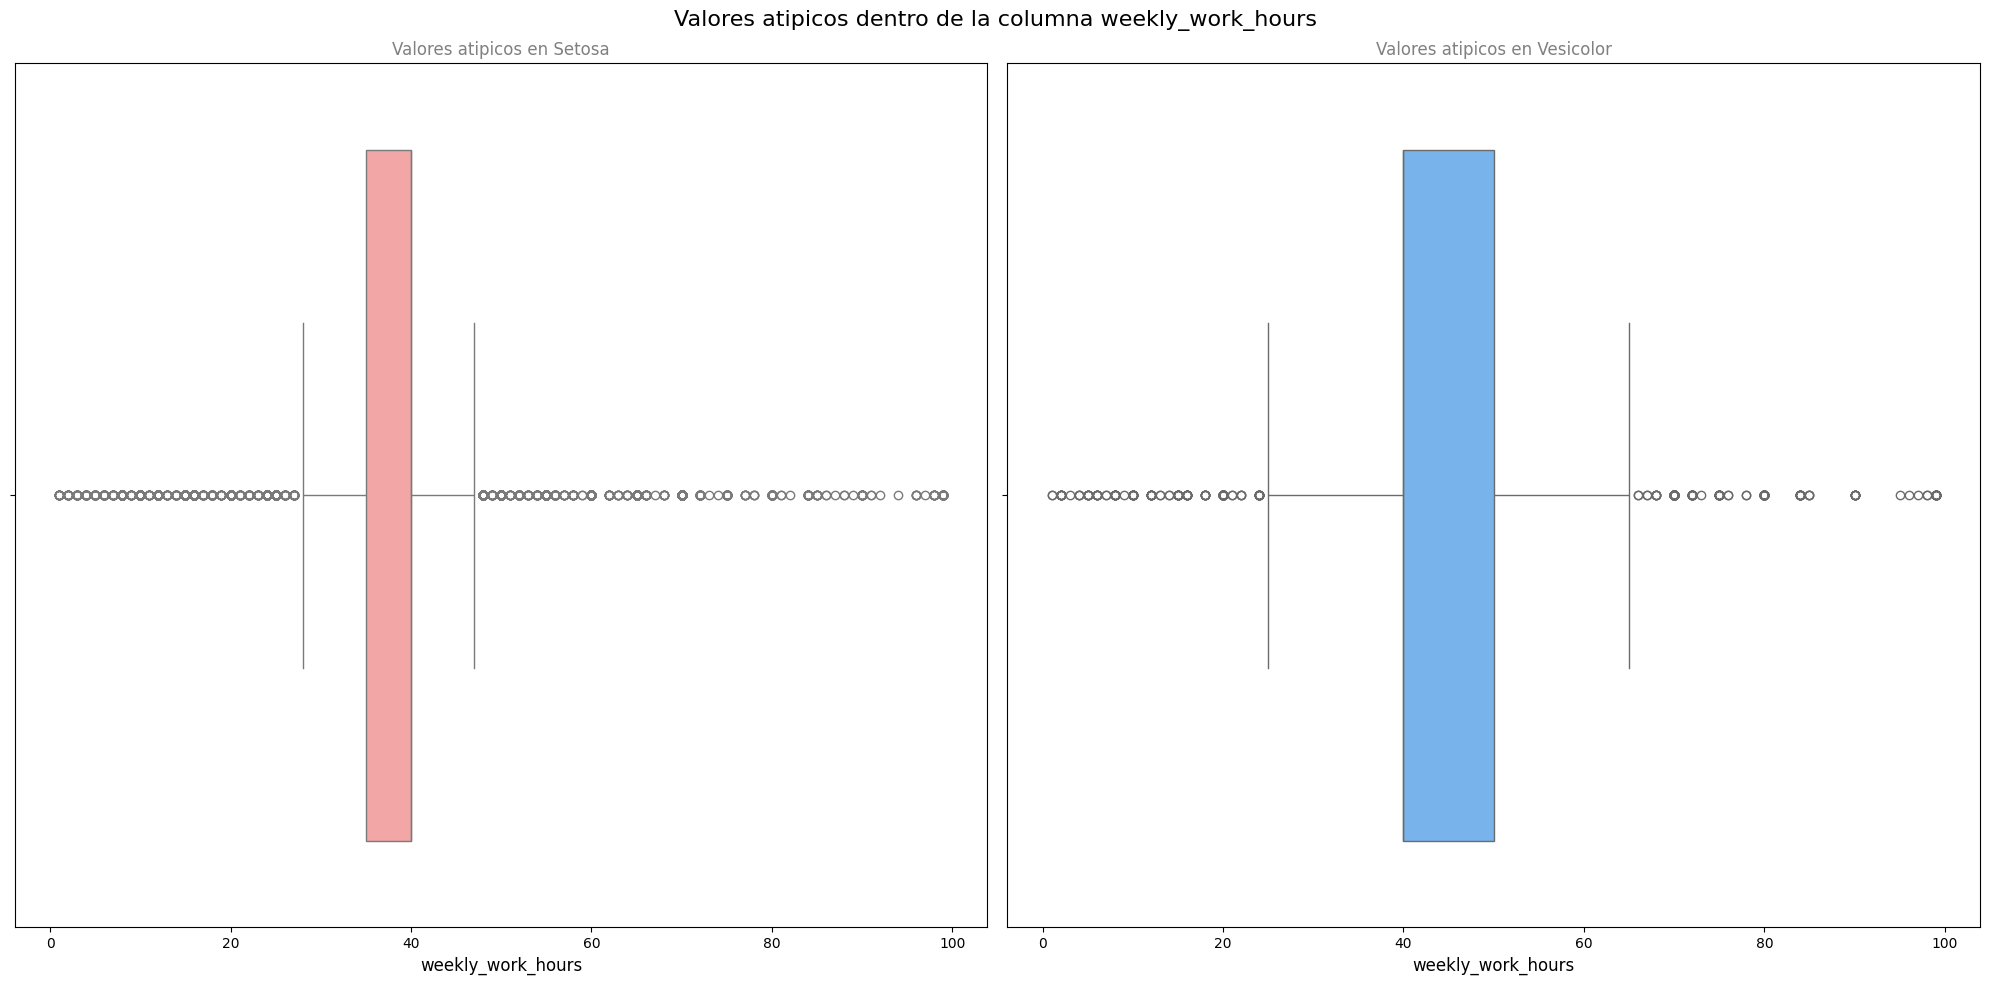

In [ ]:
for nombre_col in columnas_numericas:
  fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20, 10))
  plt.suptitle(t=f'Valores atipicos dentro de la columna {nombre_col}', fontsize=16, color='black')

  # grafico de caja
  sns.boxplot(data=df_limpio_menor_50, x=nombre_col, ax=ax[0], color=colores_income_annual['<=50K'])
  ax[0].set_title('Valores atipicos en Setosa', fontsize=12, color='grey')

  # grafico de caja
  sns.boxplot(data=df_limpio_mayor_50, x=nombre_col, ax=ax[1], color=colores_income_annual['>50K'])
  ax[1].set_title('Valores atipicos en Vesicolor', fontsize=12, color='grey')

  plt.tight_layout()

  plt.show()

  print()

Analizando outliers que ademas esten fuera de rangos logicos

In [ ]:
mask_atipicos_no_logicos = (df_limpio['weekly_work_hours'] > (12 * 7))

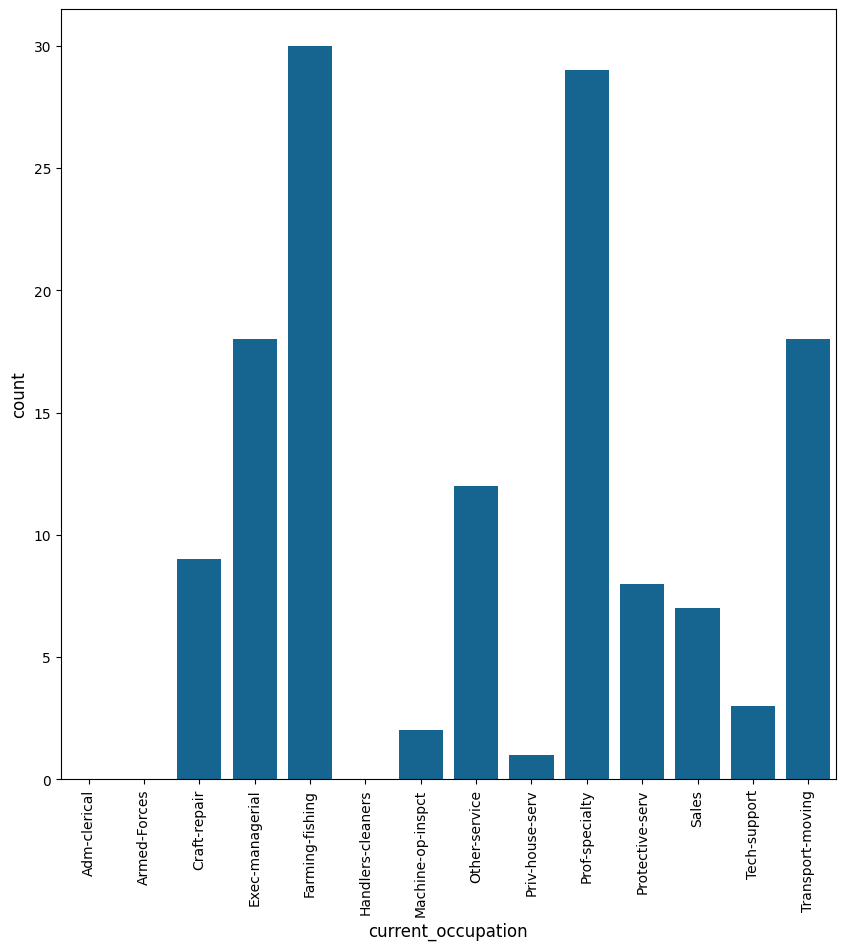

In [ ]:
plt.figure(figsize=(10, 10))
sns.barplot(df_limpio[mask_atipicos_no_logicos]['current_occupation'].value_counts())
plt.xticks(rotation=90)
plt.show()

In [ ]:
mask_weekly_work_hours_99 = df_limpio['weekly_work_hours'] == 99

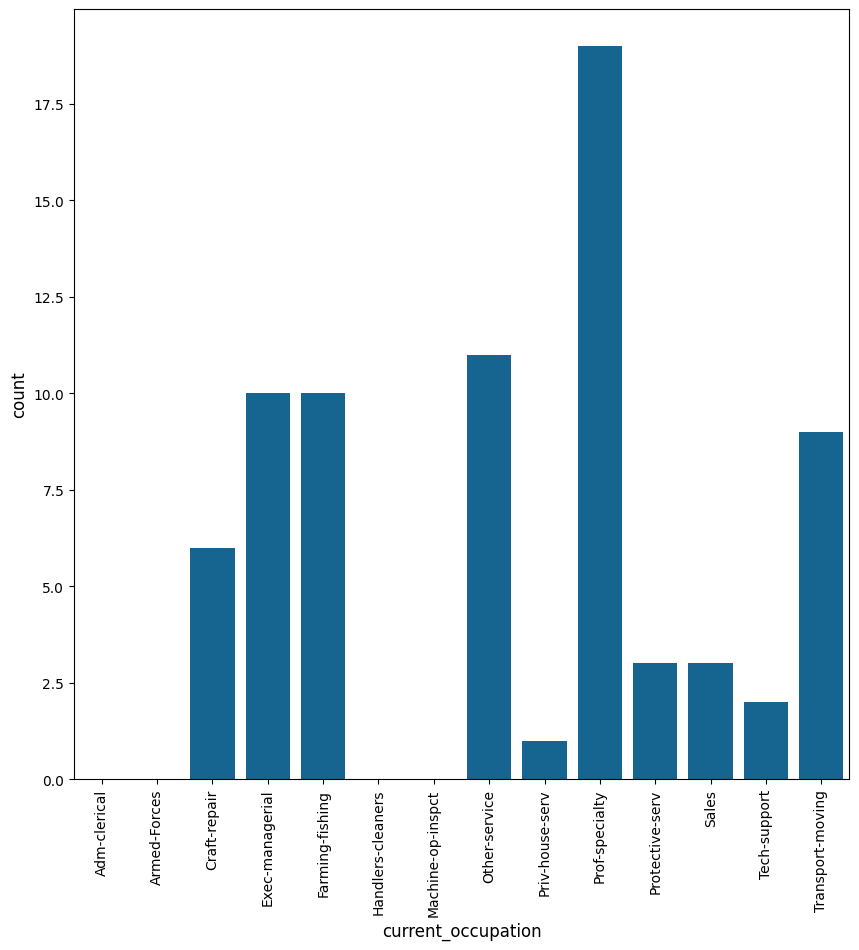

In [ ]:
plt.figure(figsize=(10, 10))
sns.barplot(df_limpio[mask_weekly_work_hours_99]['current_occupation'].value_counts())
plt.xticks(rotation=90)
plt.show()

##### Distribuciones

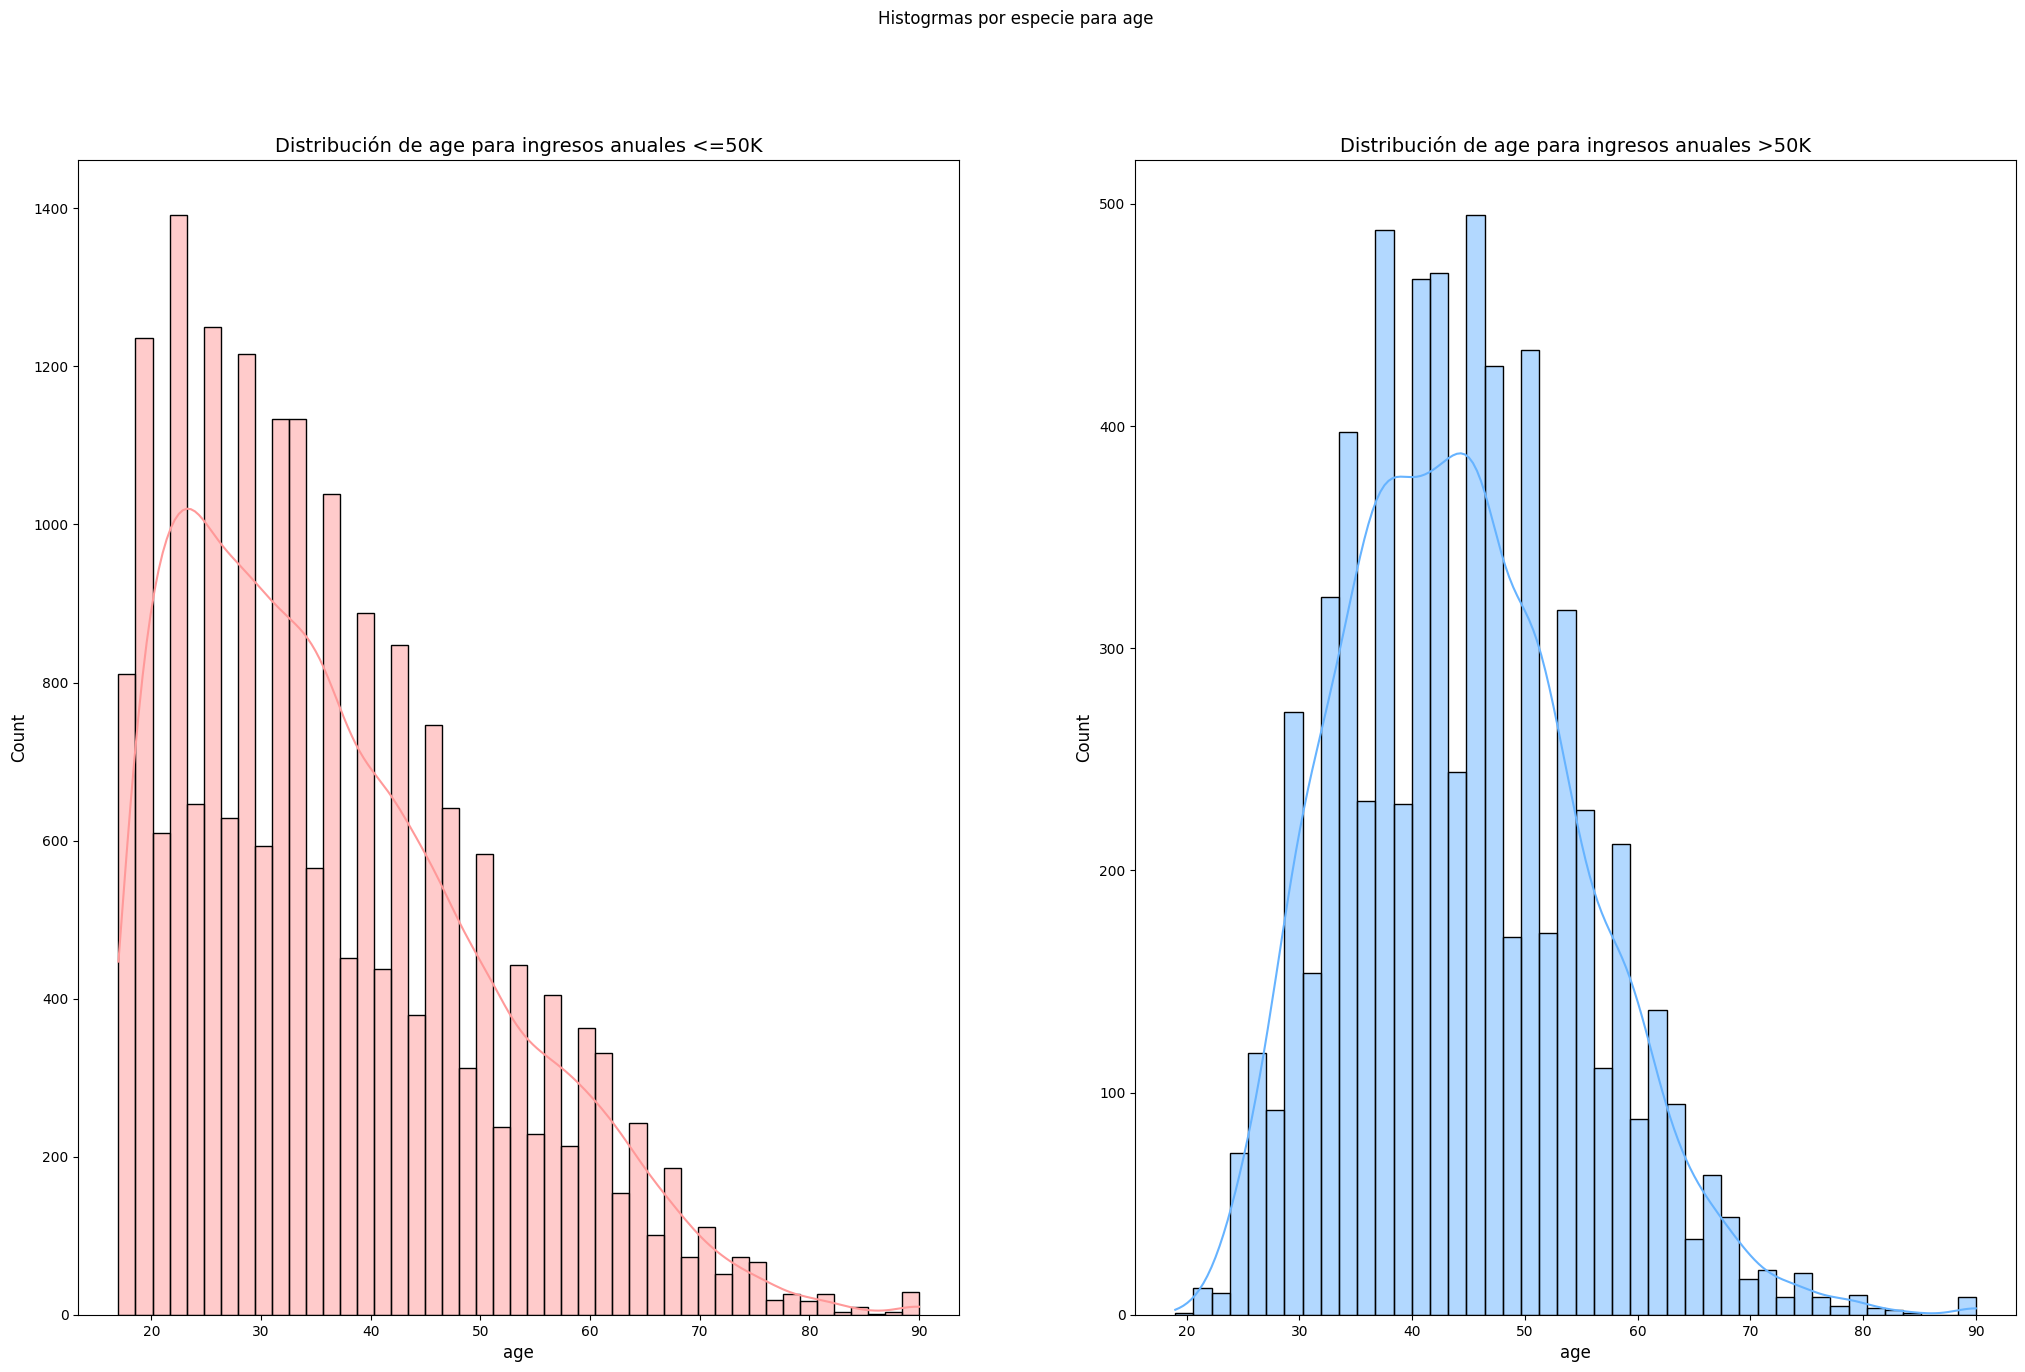

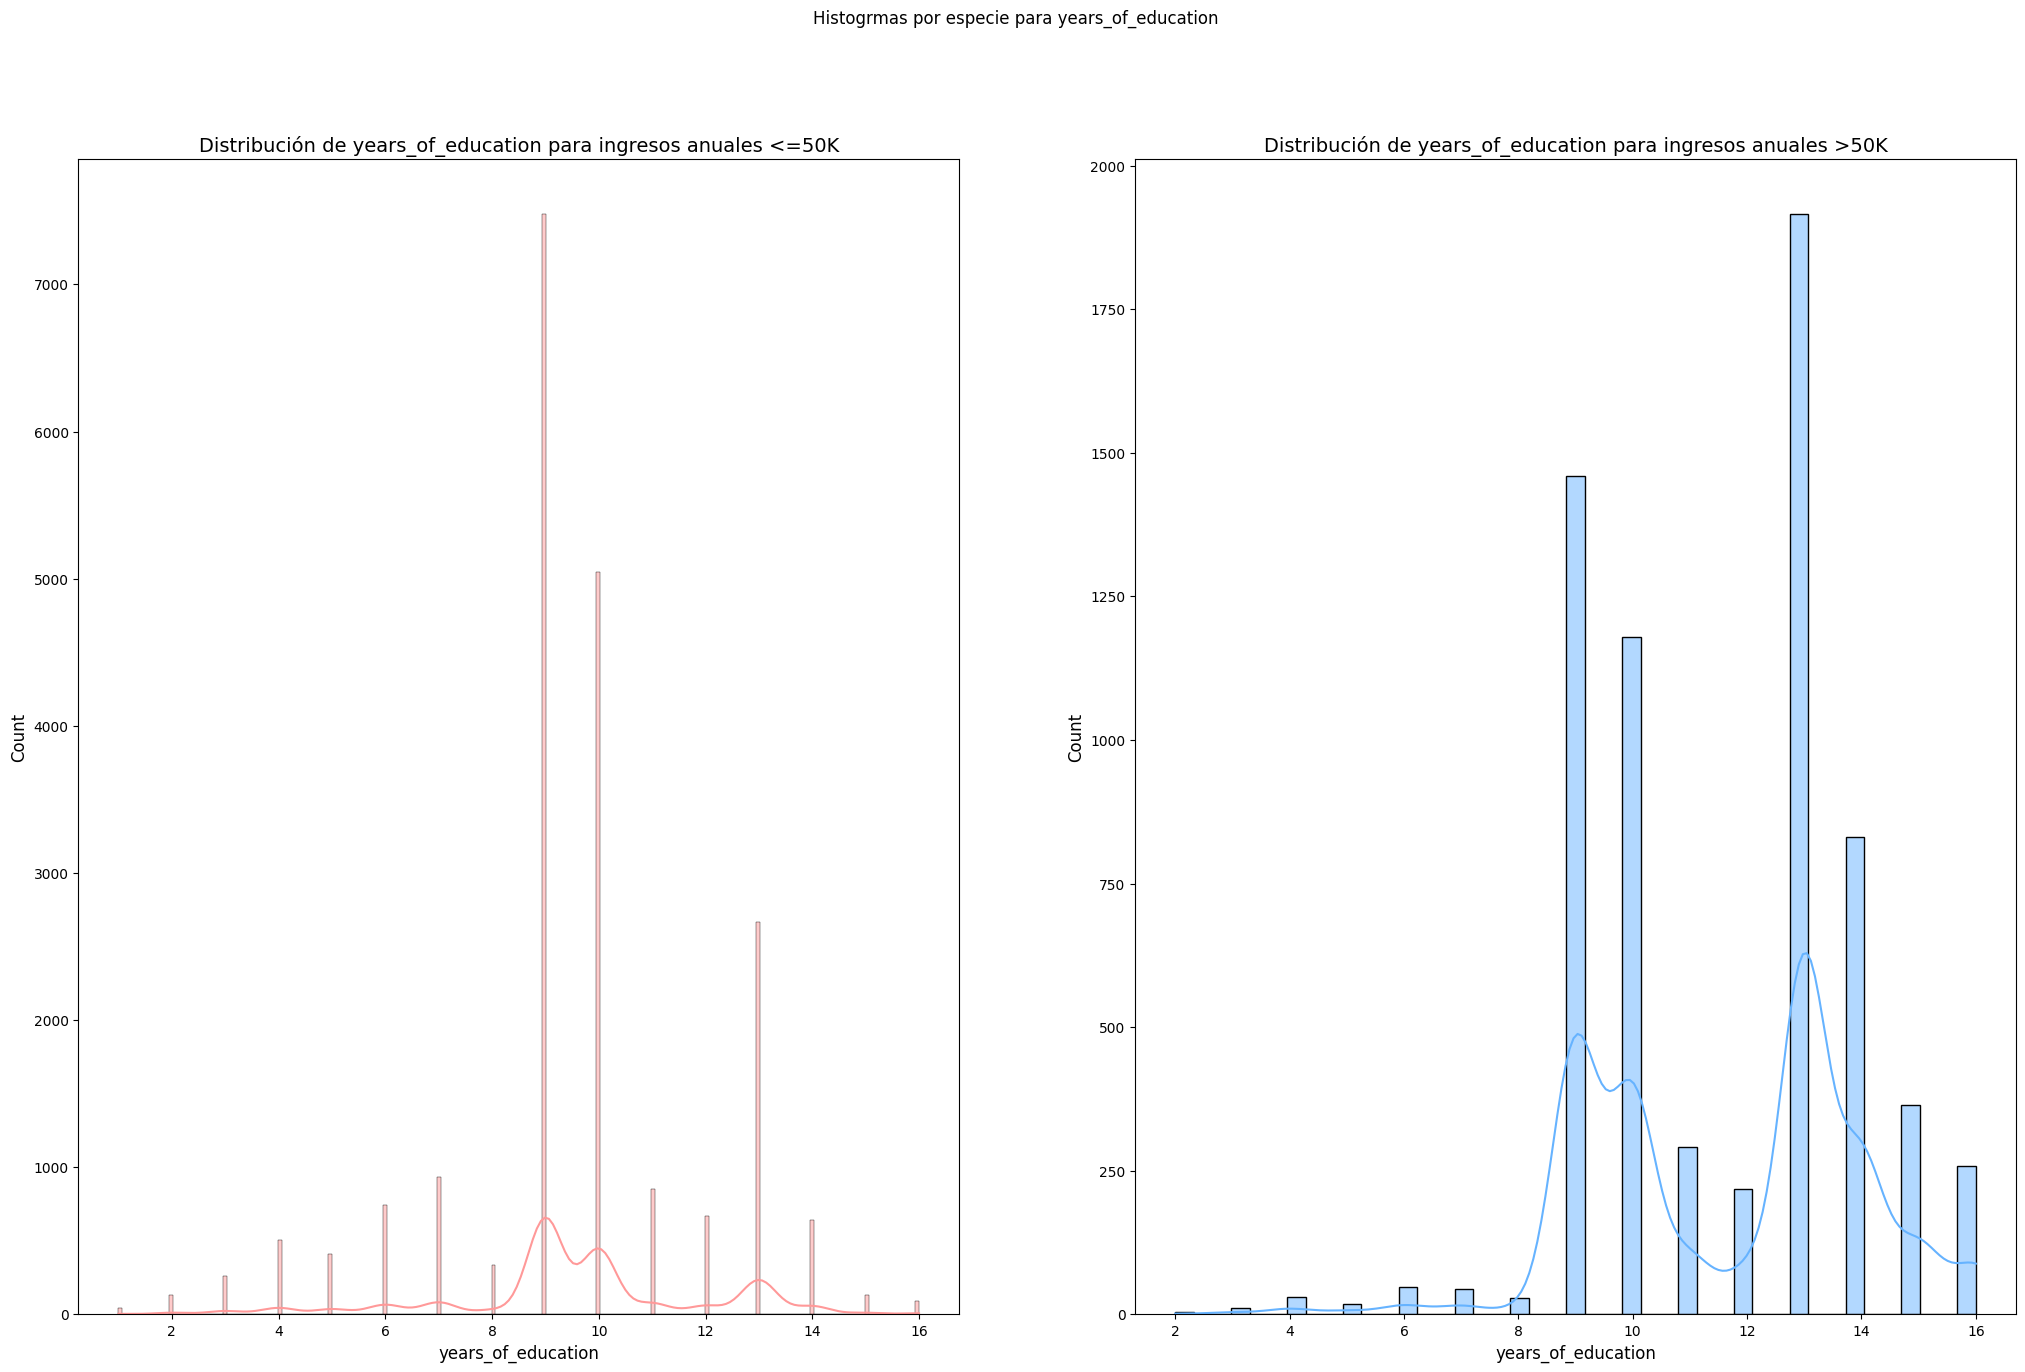

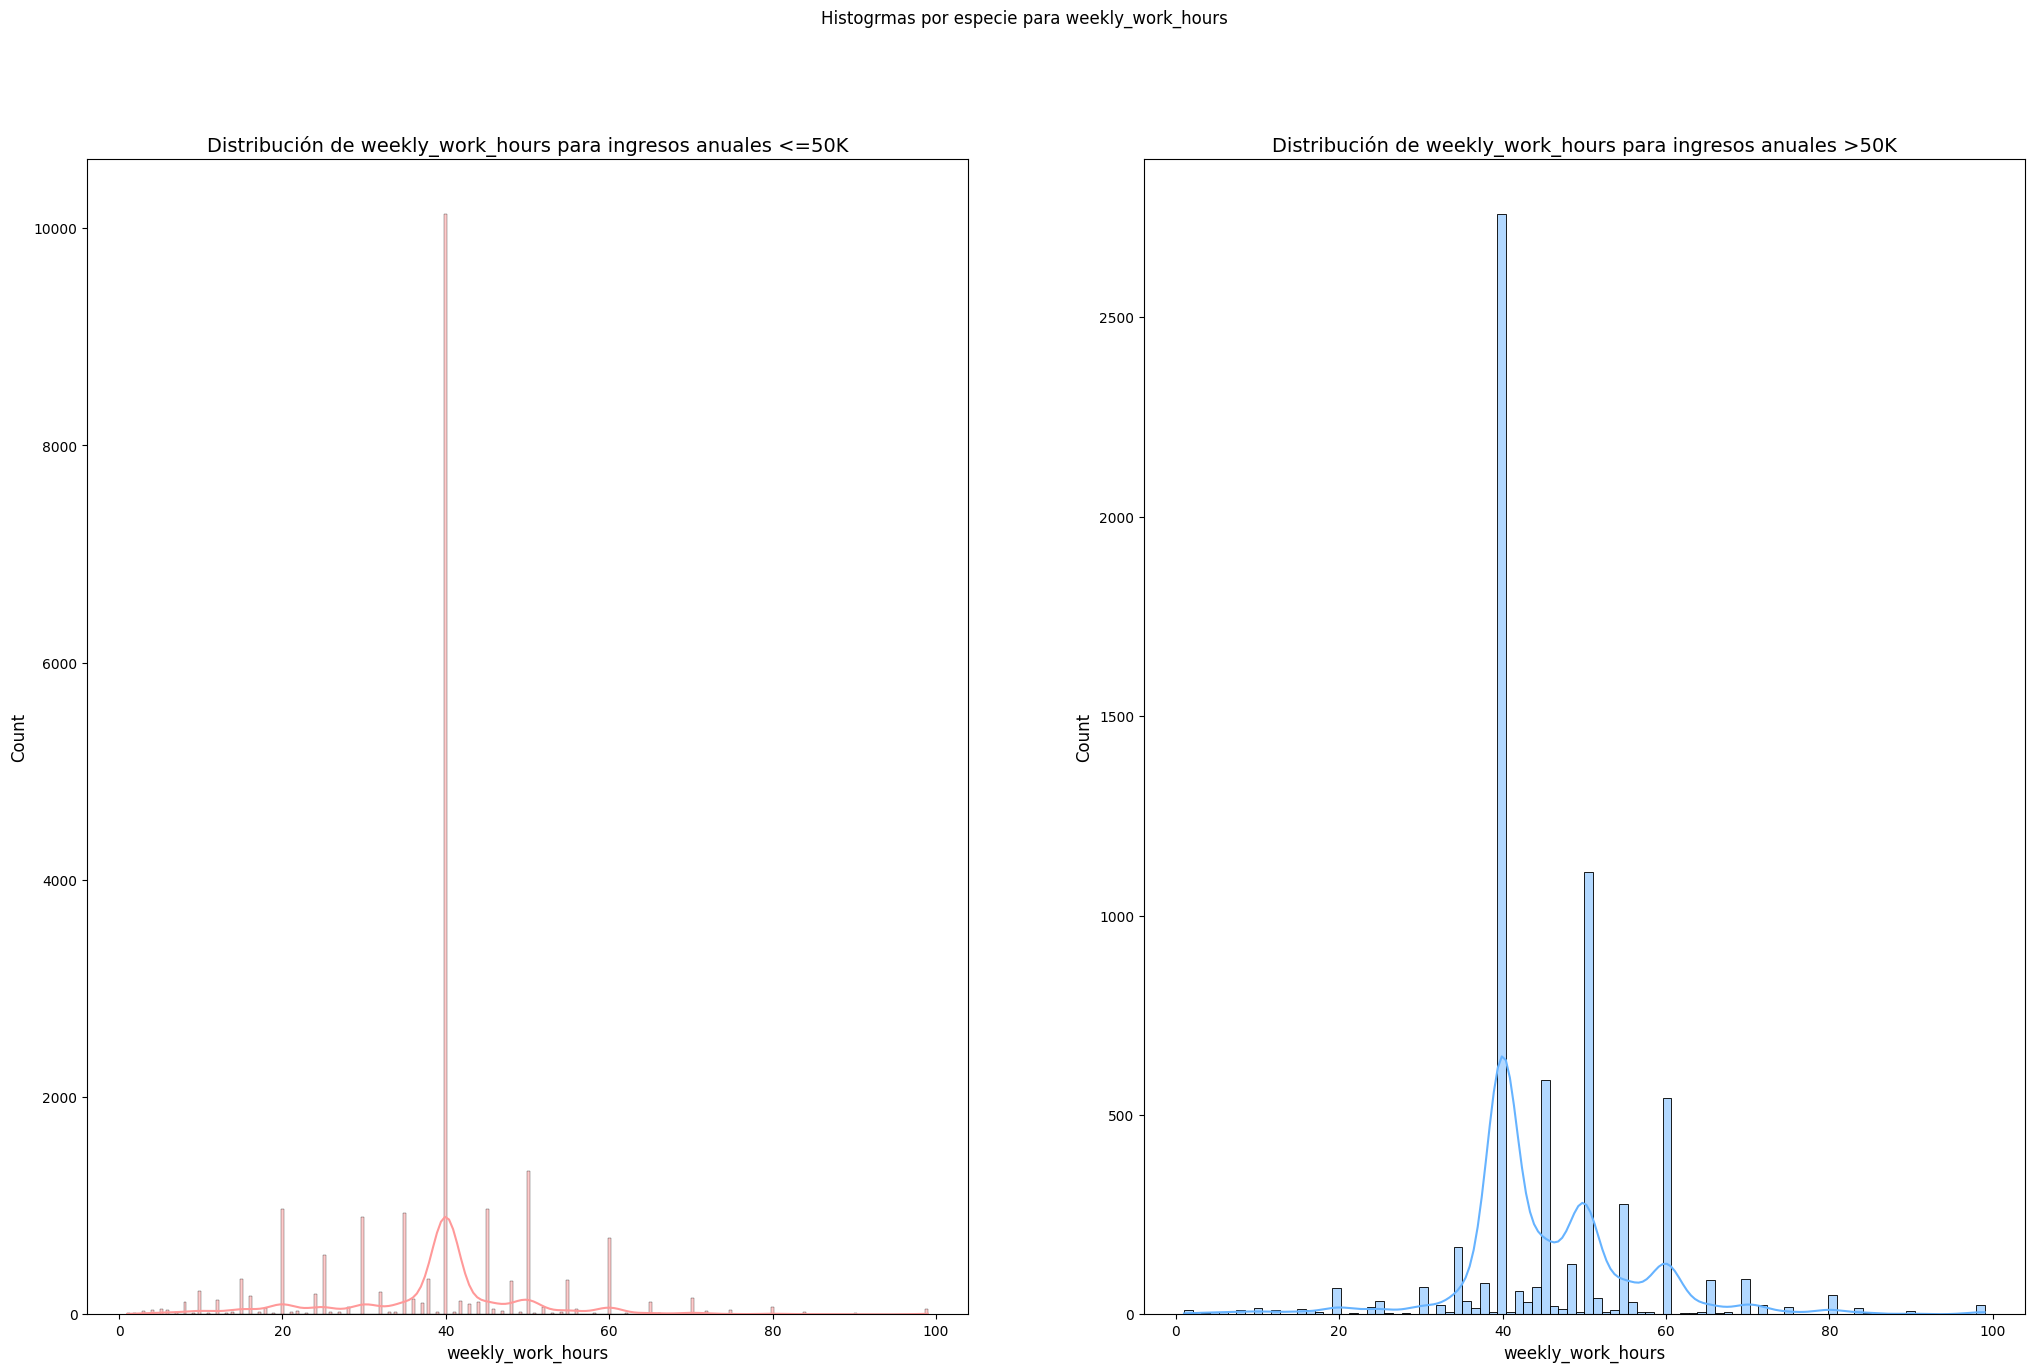

In [ ]:
for nombre_col in columnas_numericas:
  fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(25, 15))
  plt.suptitle(t=f'Histogrmas por especie para {nombre_col}')

  # histograma con kde para '<=50K'
  c_bins_lp_setosa = bins_calculator_fd(df=df_limpio_menor_50, column=nombre_col)
  sns.histplot(data=df_limpio_menor_50, x=nombre_col, kde=True, bins=c_bins_lp_setosa, ax=ax[0], color=colores_income_annual['<=50K'])
  ax[0].set_title(f'Distribución de {nombre_col} para ingresos anuales <=50K')

  # histograma con kde para '>50K'
  c_bins_lp_versicolor = bins_calculator_fd(df=df_limpio_mayor_50, column=nombre_col)
  sns.histplot(data=df_limpio_mayor_50, x=nombre_col, kde=True, bins=c_bins_lp_versicolor, ax=ax[1], color=colores_income_annual['>50K'])
  ax[1].set_title(f'Distribución de {nombre_col} para ingresos anuales >50K')

  plt.show()

  print()

##### Correlacion entre variables numericas

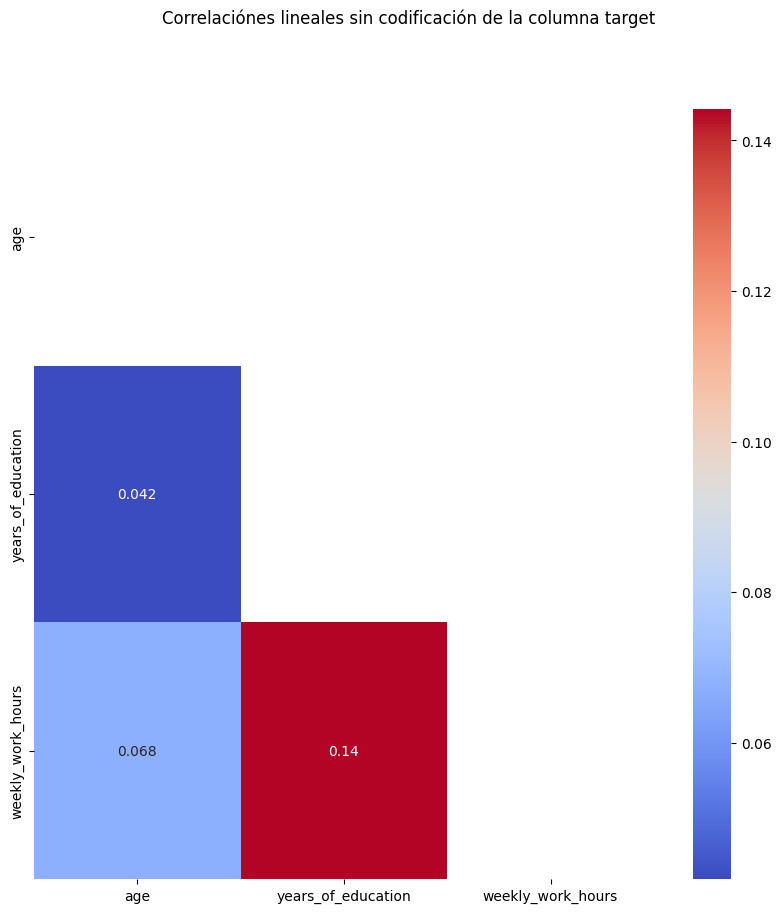

In [ ]:
# matriz de correlación
matriz_corr = df_limpio.corr(numeric_only=True)
mask_matriz_corr = np.triu(matriz_corr)

fig = plt.figure(figsize=(10, 10))
ax = sns.heatmap(data=matriz_corr, annot=True, cmap='coolwarm', mask=mask_matriz_corr)
plt.suptitle(t='Correlaciónes lineales sin codificación de la columna target')
plt.show()

##### Observaciones de la etapa

- Valores atipicos:
  - Generales: Se siguen obvservando los mismos patrones en la precencia de dichos valores a travez de todas las columnas.
  - Valores atipicos fuera del rango logico: En `weekly_work_hours` a partir de los valores algo poco esperado como, mayores a 90horas semanales, se obvserva mayor precencia de weekly_work_hours en 99 horas, lo que podria dar a pensar que se utilizo como equivalencia para especificar valor desconocido, pero haciendo foco en ello, no se ecnuentra ningún patron extrańo respecto a columnas interesantes en ese sentido, como  `current_occupation`.




- **Cdistribuciones:**
  - Sobre la clase `<=50K` se siguen observando distribuciones muy similares, mietras que en la otra clase se ve como introduce mayor ruido, ya que hay varios picos que podrian estar indicando varias modas en otras de las categorias de algunas de las demas columnas.

- **Correlaciones lineales entre columnas numericas:**
  - En general no seobvservan correlaciones significvaivas, la correlacion mas fuerte es de 0.14 entre `weekly_work_hours` y `years_of_education`.

---

## Tratamiento de datos

In [ ]:
X = df_limpio.drop(columns=['annual_income']).copy()
y = df_limpio['annual_income'].copy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

### Codificacion

Nominales

In [ ]:
# columnas a imputar
columnas_imputar = ['work_sector', 'current_occupation', 'native_country']

# Columnas categóricas
columnas_categoricas_nom = ['work_sector', 'current_occupation', 'race', 'binary_gender', 'native_country']
columnas_categoricas_ord = ['highest_education_level', 'marital_status']

# Orden para columnas ordinales
orden_categorias = [
    [
        'unfinished', 'HS-grad', 'Some-college', 'Assoc-acdm',
        'Assoc-voc', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate'
    ],
    [
        'Never-married', 'Married-AF-spouse', 'Married-civ-spouse',
        'Married-spouse-absent', 'Separated', 'Divorced', 'Widowed'
    ]
]


In [ ]:
pipe_cat_1 = Pipeline(
    steps=[
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]
)

cat_transform = ColumnTransformer(
    transformers=[
        # OneHot para columnas nominales
        ('imp_oh', pipe_cat_1, columnas_imputar),
        ('oh', OneHotEncoder(sparse_output=True, handle_unknown='ignore'), [col for col in columnas_categoricas_nom if col not in columnas_imputar]),
        # OrdinalEncoder para columnas ordinales
        ('ord_e', OrdinalEncoder(categories=orden_categorias), columnas_categoricas_ord)
    ],
    remainder='passthrough', force_int_remainder_cols=False
)

### Escalamiento

In [ ]:
# ---

### Pipeline transformación completa

In [ ]:
transform = Pipeline(
    steps=[
        ('cat_t', cat_transform),
        # apliocamos RobustScaler sobre el total de filas de salida, incluyendo las codificadas
        ('rob_e', RobustScaler())
    ]
)

In [ ]:
transform.fit(X_train)

Pipeline(steps=[('cat_t',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('imp_oh',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('oh',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['work_sector',
                                                   'current_occupation',
                                                   'native_country']),
                                                 ('oh',
                                                  OneHotEncoder(handle_unknown='ignor...
                                                  ['race', 'binary_gender']),
                                                 ('ord_e',
                                                  OrdinalEncoder(categories=[['unfinished',
                                                                              'HS-grad',
                                                                              'Some-college',
                                                                              'Assoc-acdm',
                                                                              'Assoc-voc',
                                                                              'Bachelors',
                                                                              'Masters',
                                                                              'Prof-school',
                                                                              'Doctorate'],
                                                                             ['Never-married',
                                                                              'Married-AF-spouse',
                                                                              'Married-civ-spouse',
                                                                              'Married-spouse-absent',
                                                                              'Separated',
                                                                              'Divorced',
                                                                              'Widowed']]),
                                                  ['highest_education_level',
                                                   'marital_status'])])),
                ('rob_e', RobustScaler())])

In [ ]:
X_train_p = transform.transform(X_train)
X_train_p_df = pd.DataFrame(data=X_train_p, columns=transform.get_feature_names_out(), index=X_train.index)

In [ ]:
X_test_p = transform.transform(X_test)
X_test_p_df = pd.DataFrame(data=X_test_p, columns=transform.get_feature_names_out(), index=X_test.index)

In [ ]:
df_procesado = pd.concat([X_train_p_df, X_test_p_df], axis=0)
df_procesado

,imp_oh__work_sector_Federal-gov,imp_oh__work_sector_Local-gov,imp_oh__work_sector_Private,imp_oh__work_sector_Self-emp-inc,imp_oh__work_sector_Self-emp-not-inc,imp_oh__work_sector_State-gov,imp_oh__work_sector_not_working,imp_oh__current_occupation_Adm-clerical,imp_oh__current_occupation_Armed-Forces,imp_oh__current_occupation_Craft-repair,imp_oh__current_occupation_Exec-managerial,imp_oh__current_occupation_Farming-fishing,imp_oh__current_occupation_Handlers-cleaners,imp_oh__current_occupation_Machine-op-inspct,imp_oh__current_occupation_Other-service,imp_oh__current_occupation_Priv-house-serv,imp_oh__current_occupation_Prof-specialty,imp_oh__current_occupation_Protective-serv,imp_oh__current_occupation_Sales,imp_oh__current_occupation_Tech-support,imp_oh__current_occupation_Transport-moving,imp_oh__native_country_United-States,imp_oh__native_country_other_country,oh__race_Amer-Indian-Eskimo,oh__race_Asian-Pac-Islander,oh__race_Black,oh__race_Other,oh__race_White,oh__binary_gender_Female,oh__binary_gender_Male,ord_e__highest_education_level,ord_e__marital_status,remainder__age,remainder__years_of_education,remainder__weekly_work_hours
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
9535,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,-1.00,-0.25,-1.00,0.10,-0.25,-0.40
4611,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.50,-1.00,-0.50,-1.25,0.00
26067,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,-1.00,0.75,-1.00,-0.45,0.75,-4.00
4453,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,-1.00,-0.25,1.00,-0.25,-0.25,-2.00
1208,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,-1.00,-0.25,0.00,0.15,-0.25,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1316,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,-1.00,0.50,0.00,-0.80,0.25,0.00
23852,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.50,0.00,0.40,1.50,2.00
9449,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,-1.00,0.75,0.00,-0.10,0.75,-2.00


### Corelaciones lineales luego de codificación y escalamiento

In [ ]:
y_bin = {'<=50K':0, '>50K':1}

y_train = y_train.replace(y_bin)
y_test = y_test.replace(y_bin)

<ipython-input-66-71564586bda4>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace(y_bin)
<ipython-input-66-71564586bda4>:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y_train = y_train.replace(y_bin)
<ipython-input-66-71564586bda4>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_t

In [ ]:
y = pd.concat([y_train, y_test])

In [ ]:
df_procesado = pd.concat([df_procesado, y], axis=1)

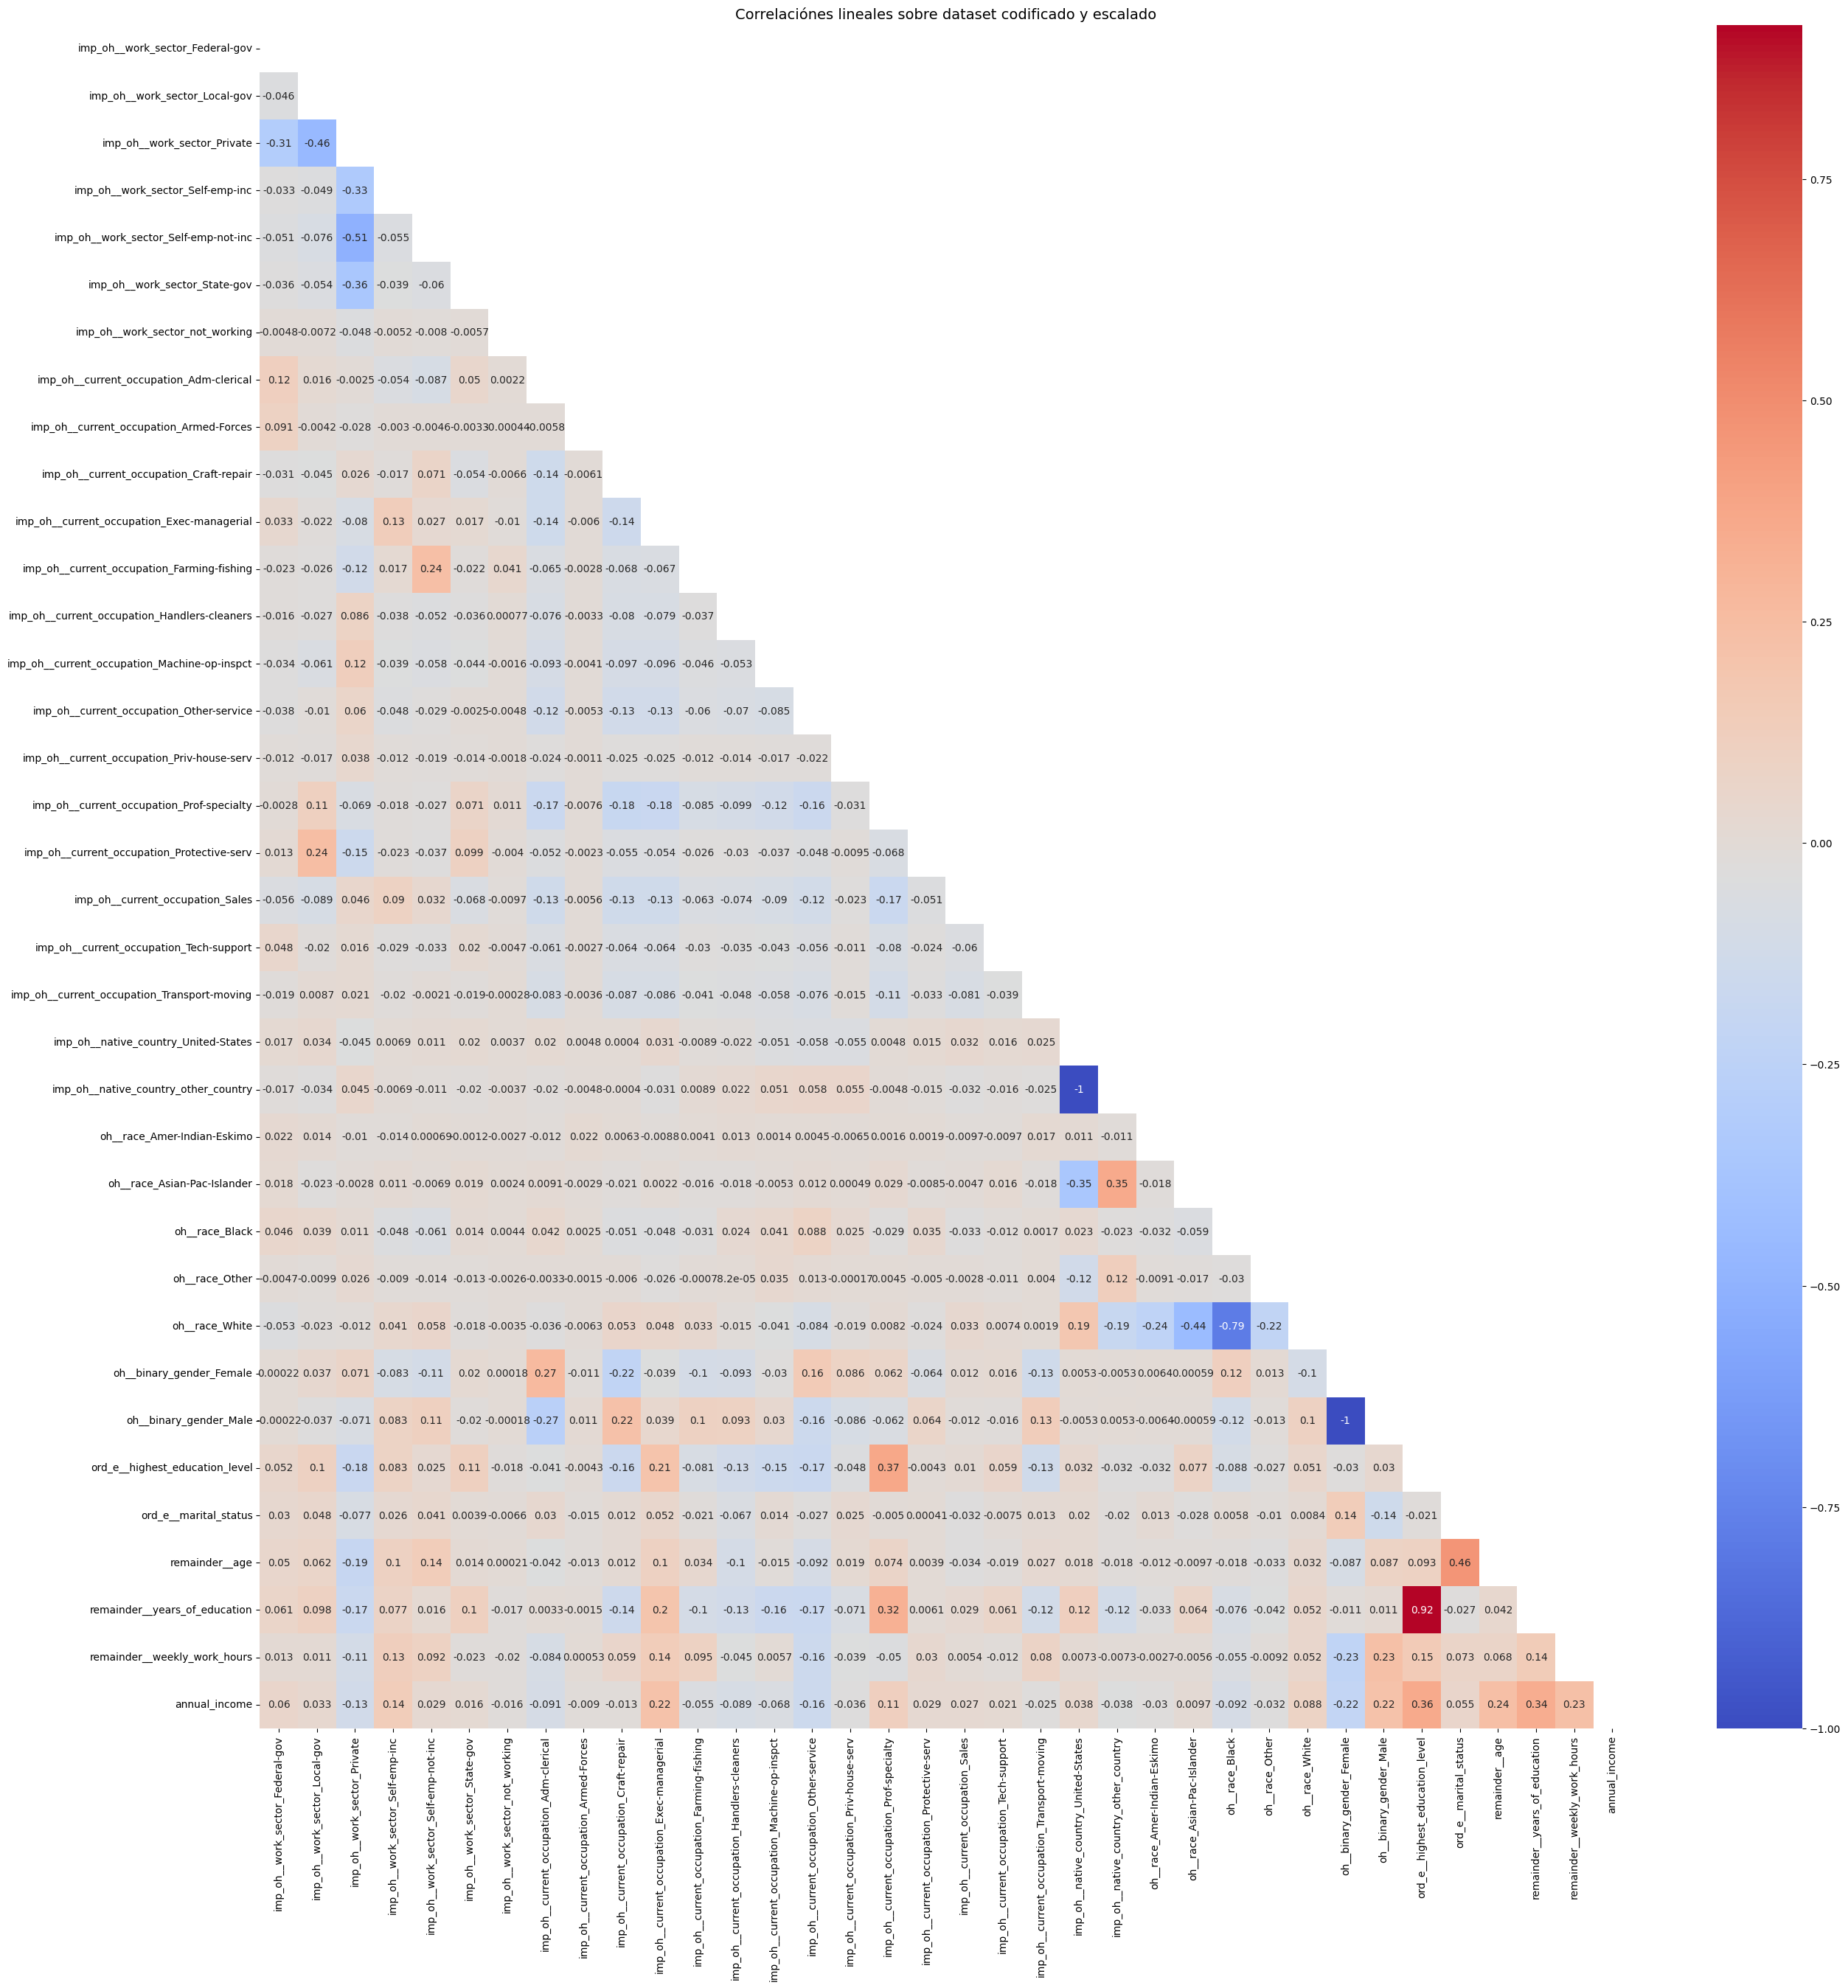

In [ ]:
df_procesado_corr = df_procesado.corr()
mask_corr = np.triu(df_procesado_corr)

plt.figure(figsize=(30, 30))
sns.heatmap(data=df_procesado_corr, annot=True, cmap='coolwarm', mask=mask_corr)
plt.title(label='Correlaciónes lineales sobre dataset codificado y escalado')
plt.show()

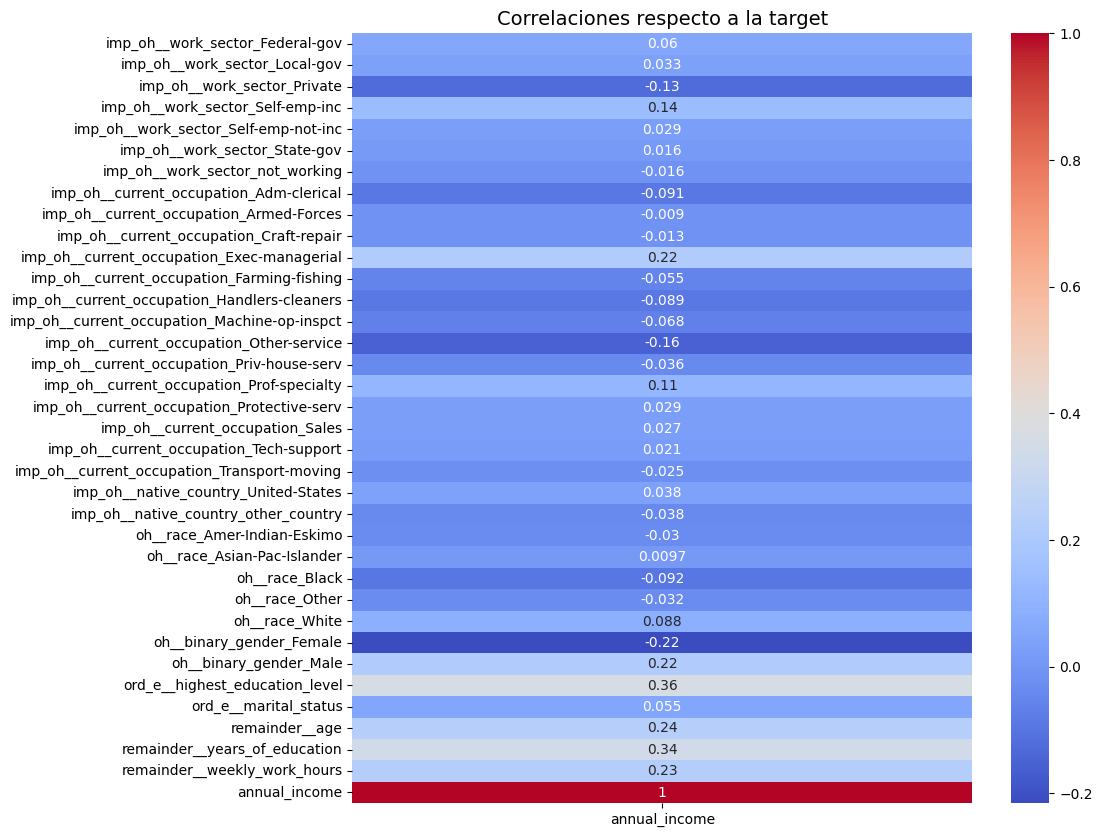

In [ ]:
plt.title('Correlaciones respecto a la target')
sns.heatmap(df_procesado_corr['annual_income'].to_frame(), annot=True, cmap='coolwarm')
plt.show()

Observación de la etapa:

- Codificación de variables categróricas: Se utilizo OneHotEncoder para todas las columnas. OK
- Escalamiento de variables numéricas: Se utilizo RobustScaler para todas las columnas. OK

---

## Analisis multivariable

Existira alguna relacion entre las vaiables?, y entre la variable categoríca con las numéricas?

In [ ]:
# implot entre cada area respecto a la target
''' plt.suptitle(t='Relación entre ')
sns.lmplot(data=, x='', y='', hue='', palette=)
plt.show() '''

" plt.suptitle(t='Relación entre ')\nsns.lmplot(data=, x='', y='', hue='', palette=)\nplt.show() "

In [ ]:
# pairplot

plt.suptitle(t=f'Relación entre cada para de columnas y la columna target')
fig = plt.figure(figsize=(15, 15))
ax = sns.pairplot(data= df_procesado, corner=True, hue='annual_income')

plt.show()

Output hidden; open in https://colab.research.google.com to view.

**Recomendaciones para las siguientes etapas:**

- Modelo elegido: Dada la precensia de outliers y poca correlación lineal con respecto a la columna target, se optara por utilizar RandomForestClassifier.

---

# Machine learning
1. RandomForestClassifier
2. LGBMClassifier
3. XGBClassifier

In [ ]:
models_param_grid = [
    {
      'model':[RandomForestClassifier(class_weight='balanced', n_jobs=-1)],
      'model__criterion':['gini', 'entropy'],
      'model__n_estimators':[130, 150, 170, 190, 200],
      'model__max_depth':[9,10, 11, 12,13,15,16, 20]
    },
    {
      'model':[LGBMClassifier(n_jobs=-1, random_state=42)],
      'model__n_estimators': [100, 120, 140, 150, 200],
      'model__max_depth': [10, 20, 30],
      'model__subsample': [0.6, 0.8, 1.0],
      'model__colsample_bytree': [0.6, 0.8, 1.0]
    },
    {
      'model': [XGBClassifier(n_jobs=-1, random_state=42)],
      'model__n_estimators': [100, 120, 130, 150, 170, 200],
      'model__max_depth': [10, 20, 30],
      'model__subsample': [0.6, 0.8, 1.0],
      'model__colsample_bytree': [0.6, 0.8, 1.0]
    }
]

pipe_final = Pipeline(
    steps=[
        ('transformacion', transform),
        ('model', [RandomForestClassifier()])
    ]
)


pipe_final_grid = GridSearchCV(estimator=pipe_final, param_grid=models_param_grid, cv=3, scoring='f1')

pipe_final_grid.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 3363, number of negative: 10465
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002459 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 238
[LightGBM] [Info] Number of data points in the train set: 13828, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.243202 -> initscore=-1.135203
[LightGBM] [Info] Start training from score -1.135203


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 3314, number of negative: 10514
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 235
[LightGBM] [Info] Number of data points in the train set: 13828, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239659 -> initscore=-1.154552
[LightGBM] [Info] Start training from score -1.154552


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

[LightGBM] [Info] Number of positive: 3314, number of negative: 10514
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 235
[LightGBM] [Info] Number of data points in the train set: 13828, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239659 -> initscore=-1.154552
[LightGBM] [Info] Start training from score -1.154552


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 3377, number of negative: 10451
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002223 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 232
[LightGBM] [Info] Number of data points in the train set: 13828, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.244215 -> initscore=-1.129710
[LightGBM] [Info] Start training from score -1.129710


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('transformacion',
                                        Pipeline(steps=[('cat_t',
                                                         ColumnTransformer(force_int_remainder_cols=False,
                                                                           remainder='passthrough',
                                                                           transformers=[('imp_oh',
                                                                                          Pipeline(steps=[('imp',
                                                                                                           SimpleImputer(strategy='most_frequent')),
                                                                                                          ('oh',
                                                                                                           OneHotEncoder(handle_unknown='ignore',
                                                                                                                         sparse_output=False))]),
                                                                                          ['work_sector',
                                                                                           'current_occupation...
                                                  max_depth=None,
                                                  max_leaves=None,
                                                  min_child_weight=None,
                                                  missing=nan,
                                                  monotone_constraints=None,
                                                  multi_strategy=None,
                                                  n_estimators=None, n_jobs=-1,
                                                  num_parallel_tree=None,
                                                  random_state=42, ...)],
                          'model__colsample_bytree': [0.6, 0.8, 1.0],
                          'model__max_depth': [10, 20, 30],
                          'model__n_estimators': [100, 120, 130, 150, 170, 200],
                          'model__subsample': [0.6, 0.8, 1.0]}],
             scoring='f1')

### Predicciones

In [ ]:
train_preds = pipe_final_grid.predict(X_train)
test_preds = pipe_final_grid.predict(X_test)

### Evaluación

In [ ]:
print('Reporte de clasificación en train:')
print(classification_report(y_true=y_train, y_pred=train_preds))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91     15715
           1       0.67      0.94      0.78      5027

    accuracy                           0.87     20742
   macro avg       0.83      0.90      0.85     20742
weighted avg       0.90      0.87      0.88     20742



In [ ]:
print('Reporte de clasificación en test:')
print(classification_report(y_true=y_test, y_pred=test_preds))

Reporte de clasificación en test:
              precision    recall  f1-score   support

           0       0.92      0.82      0.86      5238
           1       0.57      0.77      0.66      1676

    accuracy                           0.80      6914
   macro avg       0.74      0.79      0.76      6914
weighted avg       0.83      0.80      0.81      6914



In [ ]:
pipe_final_grid.best_estimator_

Pipeline(steps=[('transformacion',
                 Pipeline(steps=[('cat_t',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    remainder='passthrough',
                                                    transformers=[('imp_oh',
                                                                   Pipeline(steps=[('imp',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('oh',
                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                  sparse_output=False))]),
                                                                   ['work_sector',
                                                                    'current_occupation',
                                                                    'native_country']),
                                                                  ('oh',
                                                                   O...
                                                                                               'Assoc-voc',
                                                                                               'Bachelors',
                                                                                               'Masters',
                                                                                               'Prof-school',
                                                                                               'Doctorate'],
                                                                                              ['Never-married',
                                                                                               'Married-AF-spouse',
                                                                                               'Married-civ-spouse',
                                                                                               'Married-spouse-absent',
                                                                                               'Separated',
                                                                                               'Divorced',
                                                                                               'Widowed']]),
                                                                   ['highest_education_level',
                                                                    'marital_status'])])),
                                 ('rob_e', RobustScaler())])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=16,
                                        n_estimators=170, n_jobs=-1))])

In [ ]:
pipe_final_grid.best_params_

{'model': RandomForestClassifier(class_weight='balanced', n_jobs=-1),
 'model__criterion': 'gini',
 'model__max_depth': 16,
 'model__n_estimators': 170}

#### Importancia de características

In [ ]:
df_fi = pd.DataFrame(columns=['features', 'importances'])

In [ ]:
df_fi['importances'] = pipe_final_grid.best_estimator_['model'].feature_importances_
df_fi['features'] = pipe_final_grid.best_estimator_['transformacion'].get_feature_names_out()
df_fi.sort_values(by='importances', ascending=False, inplace=True)

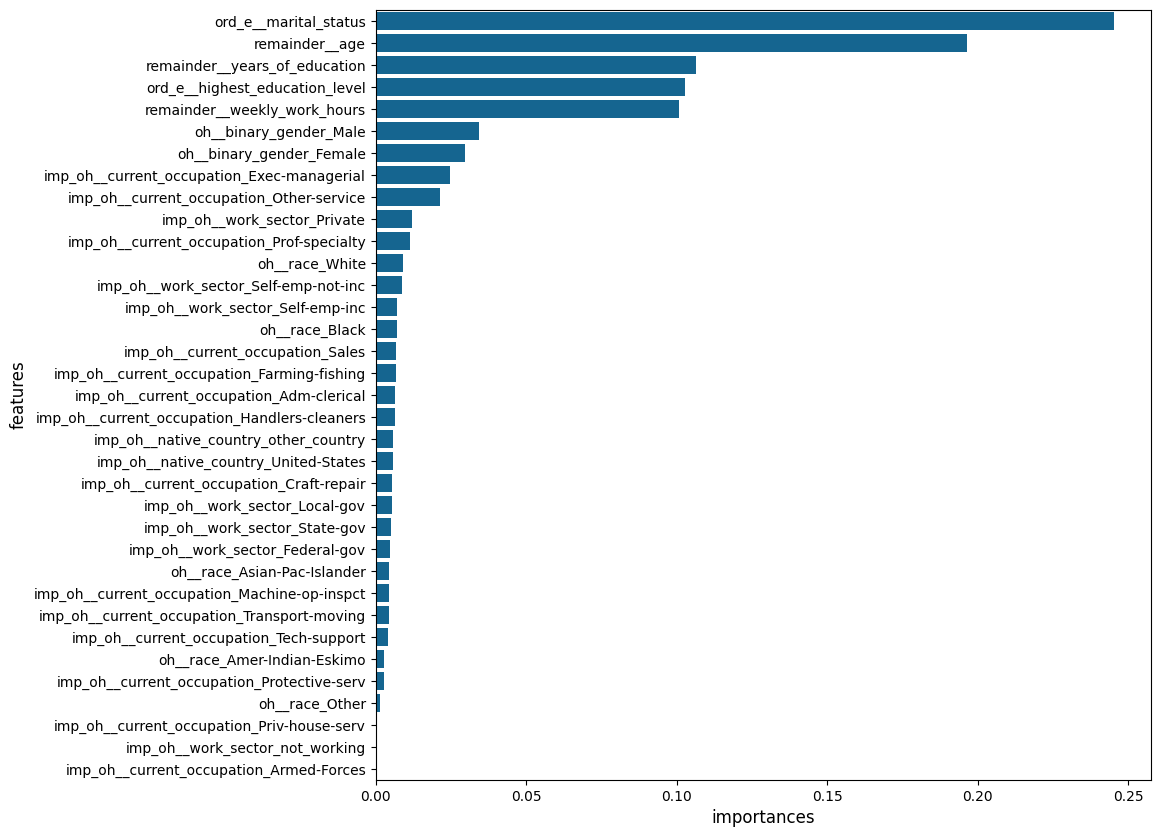

In [ ]:
plt.figure(figsize=(10, 10))
sns.barplot(data=df_fi, x='importances', y='features')
plt.show()

## Predicciones sobre `df_test` utilizando el mejor modelo

In [ ]:
preds = pipe_final_grid.predict(df_test)

In [ ]:
submit_df = pd.DataFrame(columns=['ID', 'preds'])
submit_df['ID'] = df_test.index
submit_df['preds'] = preds

In [ ]:
submit_df

,ID,preds
0,3643,1
1,16036,0
2,9401,1
3,17903,1
4,5198,1
...,...,...
4876,19468,0
4877,7554,1
4878,25076,0
4879,9731,0


---

# Almacenamiento de utilidades

### Dataframes modificados

In [ ]:
!mkdir data

Dataframe limpio

In [ ]:
df_limpio.to_csv('./data/income_annual_limpio.csv')

Dataframe por clase

In [ ]:
df_limpio_mayor_50.to_csv('./data/income_annual_limpio_mayor_50.csv')
df_limpio_menor_50.to_csv('./data/income_annual_limpio_manor_50.csv')

Dataframe procesado

In [ ]:
df_procesado.to_csv('./data/income_annual_procesado.csv')

Predicciones sobre el conjunto. detest original

In [ ]:
submit_df.to_csv('./submit_preds_test.csv')

### Transformadores entrenados

In [ ]:
!mkdir transformadores

In [ ]:
joblib.dump(transform, './transformadores/pipe_transfomracion.joblib')

['./transformadores/pipe_transfomracion.joblib']

### Modelos de machine learning entrenados

In [ ]:
!mkdir models

In [ ]:
joblib.dump(final_pipe_2_grid.best_estimator_['model_lgbm'], './transformadores/rf_best_model.joblib')

['./transformadores/rf_best_model.joblib']